## Replicate One-Loop Simulation from STDP-SR Repo
Run simulations in a open 1D loop maze with and without theta and ideally vary the theta frequency later

In [2]:
# Imports
import sys # for path management
sys.path.insert(0, "/Users/liviastein/STDP_Theta-1/STDP-SR_scripts")  # Ensure current directory is in path
from MazeAgent_Script import *  # import all functions from MazeAgent_Script
import copy

%load_ext autoreload
%autoreload 2

#for plotting in notebook
%matplotlib inline  

### STDP Learning in Loop Maze

Setting parameters
Initialising
   making state/history dataframes
   initialising velocity, position and direction
   setting time/run counters
   making the maze walls
   discretising position for later plotting
   handling undefined parameters
   initialising basis features for learning
   calculating state vector at all discretised positions


  0%|          | 0/10000 [00:00<?, ?it/s]

   initialising STDP weight matrix and traces
DONE


(<Figure size 4000x160 with 1 Axes>, <Axes: >)

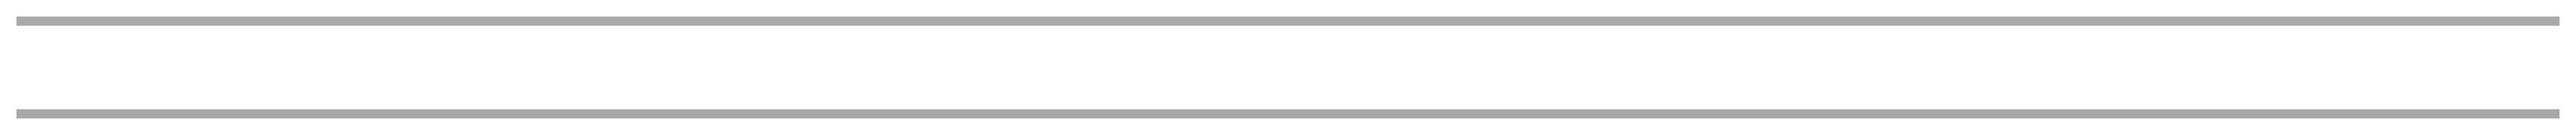

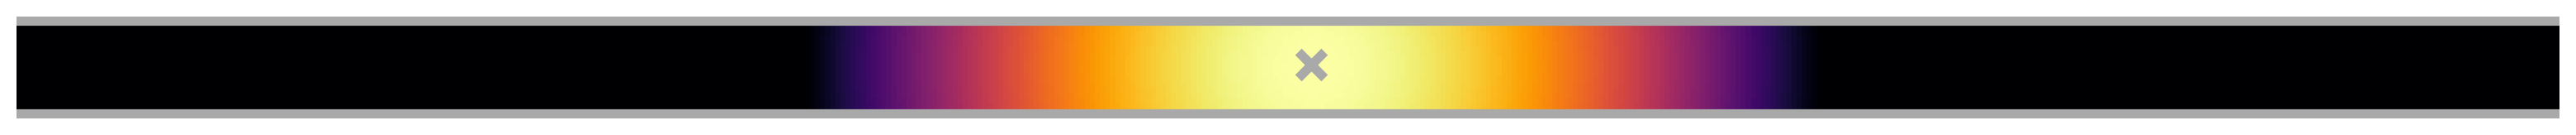

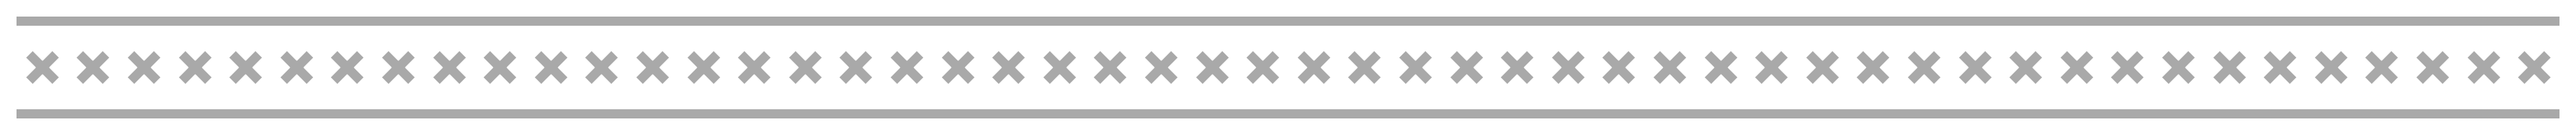

In [35]:
## Define parameters for maze and agent
# number of placeCells
N=50

# set x and y coordinates for place cell centres
xcen = np.linspace(0,5,N+1)[:-1] # we want to place N place cells evenly across the 5m length of the maze, so we create N+1 evenly spaced points and then take all but the last one (which is at 5m) to get the centres of the place cells.
xcen += (xcen[1] - xcen[0]) / 2 # we want the first place cell to be centred at 0.1m, so we shift all the centres by half the distance between them (i.e. the distance between the first centre and 0m) to get the final x coordinates of the place cell centres.
ycen = np.array([0.1]*N) # we want all the place cells to be centred at 0.1m in the y direction (i.e. 10cm from the south wall) so we set all the y coordinates of the place cell centres to 0.1m.
centres = np.vstack((xcen,ycen)).T # we combine the x and y coordinates into a single array of shape (N,2) where each row is the (x,y) coordinates of a place cell centre.

# set parameters for the MazeAgent class
params = {
          'mazeType'           : 'loop',  #type of maze, define in getMaze() function
          'stateType'          : 'gaussianThreshold', #feature on which to TD learn (onehot, gaussian, gaussianCS, fourier)
          'movementPolicy'     : 'windowsScreensaver',  #movement policy  -> follows walls for long time, i.e. one direction
          'roomSize'           : 5,          #maze size scaling parameter, metres
          'dt'                 : 0.005,       #simulation time disretisation 
          'dx'                 : 0.01,       #space discretisation (for plotting, movement is continuous)
          'tau'                : 5,          #TD decay time, seconds
          'TDdx'               : 0.02,       #rough distance between TD learning updates, metres 
          'alpha'              : 0.1,       #TD learning rate 
          'nCells'             : N,       #how many features to use
          'peakFiringRate'     : 5,         #peak firing rate of a cell (middle of place field, preferred theta phase)
          'centres'            : centres,       #array of receptive field positions. Overwrites nCells
          'speedScale'         : 0.16,       #movement speed scale, metres/second
          'rotSpeedScale'      : None,       #rotational speed scale, radians/second
          'initPos'            : None,       #initial position [x0, y0], metres
          'initDir'            : None,       #initial direction, unit vector
          'sigma'              : 1,        #feature cell width scale, relevant for  gaussin, gaussianCS, circles
          'doorsClosed'        : False,       #whether doors are opened or closed in multicompartment maze
          'eta'                : 0.01,       #STDP learning rate
          'online_mapping'     : 'identity',
          'use_full_STDP_rule' : True,
          'rownorm'            : False,
}

agent = MazeAgent(params)
plotter = Visualiser(agent)
agent.toggleDoors(params['doorsClosed'])

plotter.plotMazeStructure() # plot maze structure to check it's correct before starting simulation
plotter.plotReceptiveField(25) # plot receptive field of place cell 25 in the middel of loop
plotter.plotFeatureCells(centresOnly=True, textlabel=False) # plots centres of the place cells in maze (no heatmap)


  0%|          | 0/360000 [00:00<?, ?it/s]

Calculating place and grid cells


(<Figure size 4000x160 with 1 Axes>, <Axes: >)

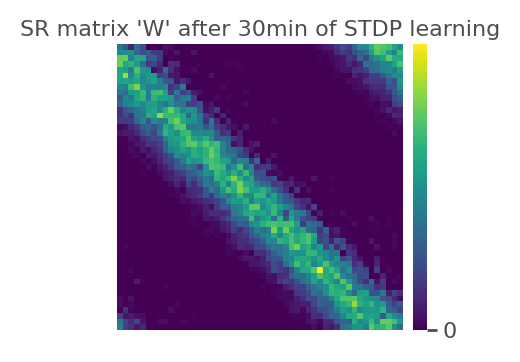

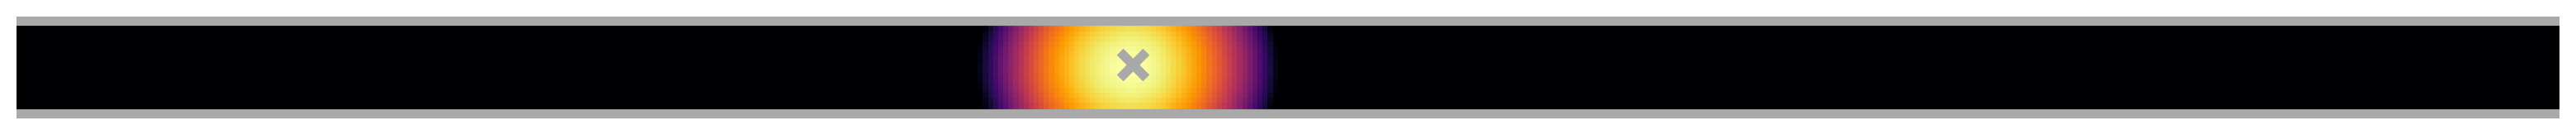

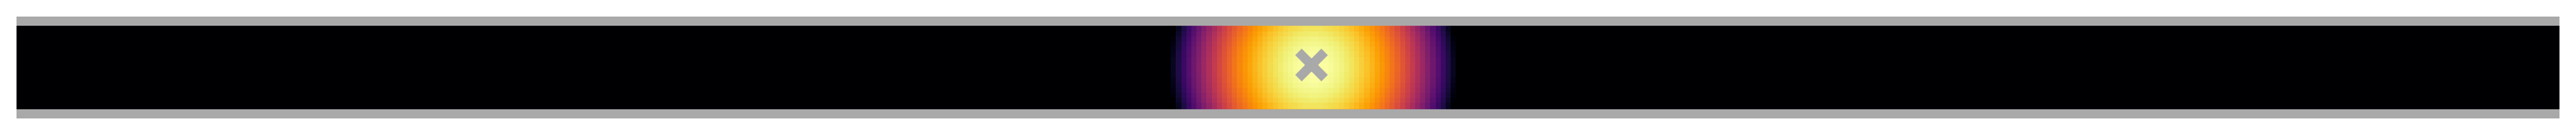

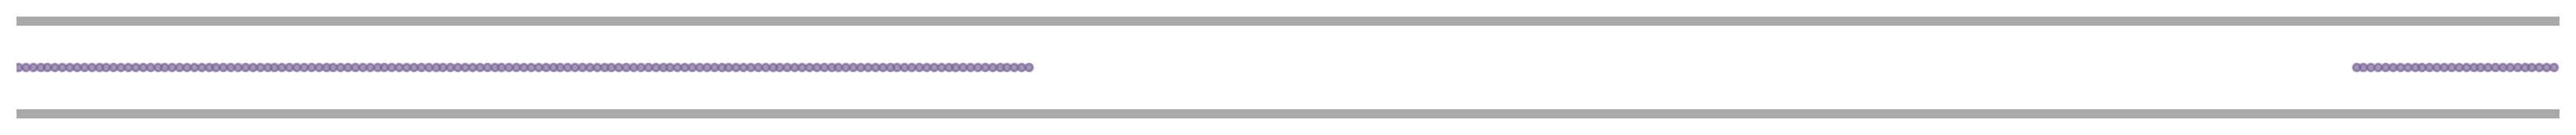

In [36]:
# Set parameters and run simulation
agent.pos = np.array([0,0.1])  
agent.dir = np.array([1,0]) # start at the west end of the loop, facing east, so we can follow the walls in a clockwise direction

# Define agent to train for 30min (as in paper), with STDP learning, no TD learning and save snapshots every 1min
agent.runRat(trainTime=30, STDPLearn=True, TDSRLearn=False,saveEvery=1)

# Define what to plot from this STDP run
plotter = Visualiser(agent) # create new plotter to access the data from the STDP run we just did
plotter.plotM(whichM="W", colorbar=True, title="SR matrix 'W' after 30min of STDP learning", save=True)
plotter.plotPlaceField(hist_id=-1, number=25, save=True, STDP=True)
plotter.plotPlaceField(hist_id=-1, number=25, save=True, STDP=False)
plotter.plotTrajectory(starttime=1,endtime=1+5/20)
# plotter.plotTrajectory(hist_id=-1, starttime=1, endtime=1+30/60, plotAsLine=False)

mass ratio = 4.3072923368365315 vs 0.9733997089724122 (no theta)
t0.5 1.000 vs t0.5notheta 1.000


/Users/liviastein/STDP_Theta-1/STDP-SR_scripts/MazeAgent_Script.py:2009: RuntimeWarning: invalid value encountered in scalar divide
  skewness = getMoment(x,y,moment=3,c=mean) / std**3


(<Figure size 200x400 with 2 Axes>, array([<Axes: >, <Axes: >], dtype=object))

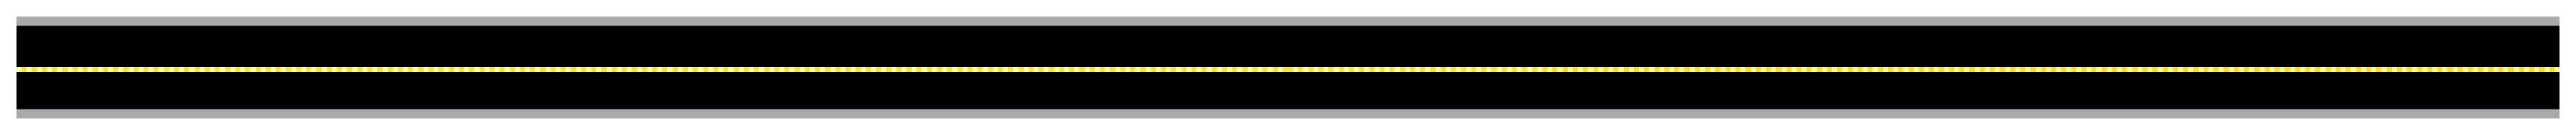

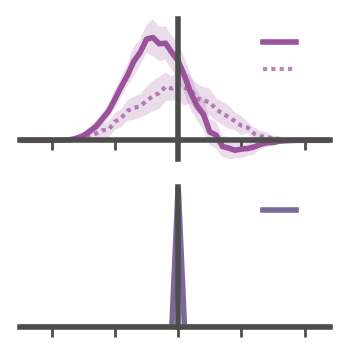

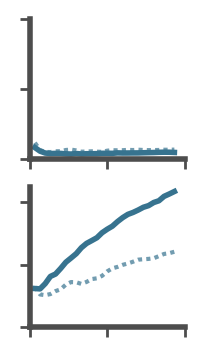

In [37]:
plotter.plotHeatMap(smoothing=1)

# make a subplot
plotter.plotMAveraged(time=None, x_ticks=None, plot_no_theta=True, color='C7',ylim=None, renorm=True)

plotter.plotMetrics(total_time=None, x_ticks=None)
 

### TD-Learning in Loop Maze

Setting parameters
Initialising
   making state/history dataframes
   initialising velocity, position and direction
   setting time/run counters
   making the maze walls
   discretising position for later plotting
   handling undefined parameters
   initialising basis features for learning
   calculating state vector at all discretised positions


  0%|          | 0/10000 [00:00<?, ?it/s]

   initialising STDP weight matrix and traces
DONE


(<Figure size 4000x160 with 1 Axes>, <Axes: >)

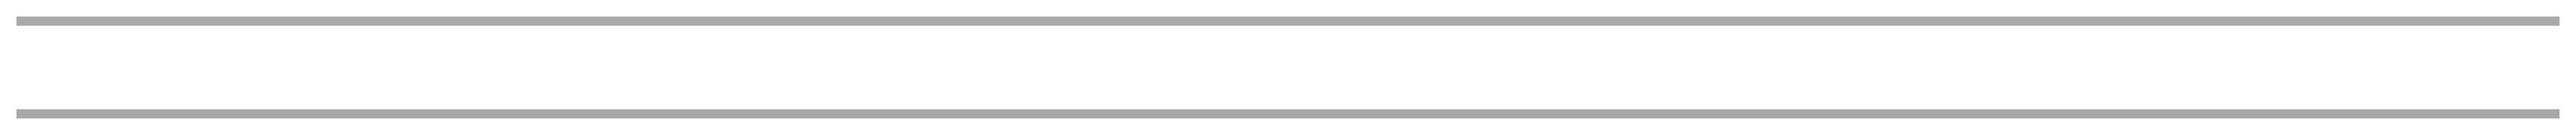

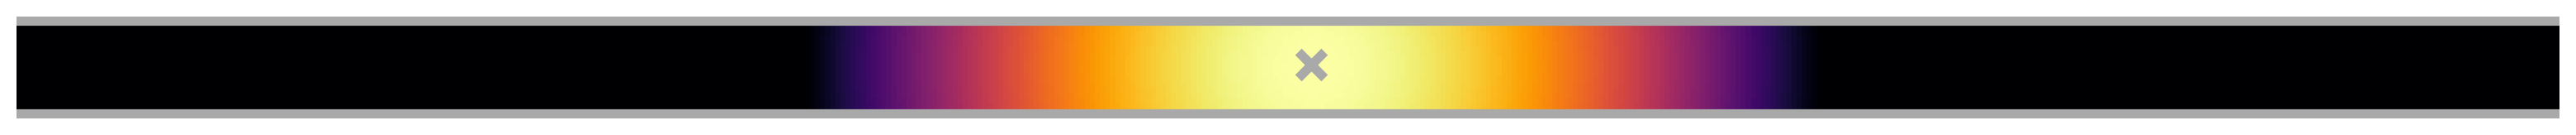

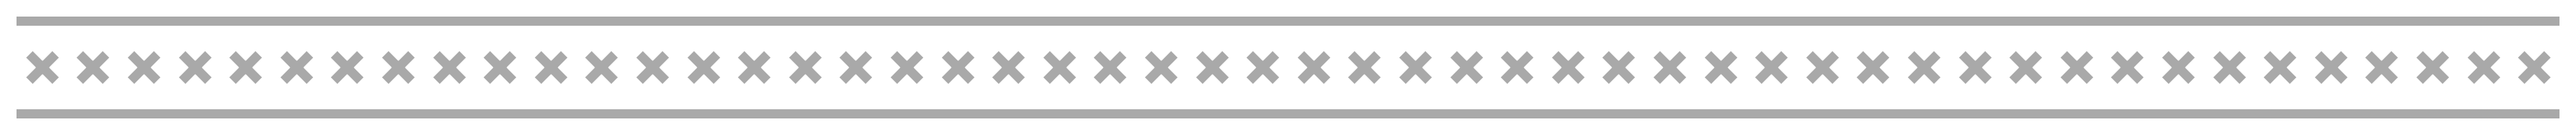

In [42]:
## Define parameters for maze and agent
# number of placeCells
N=50

# set x and y coordinates for place cell centres
xcen = np.linspace(0,5,N+1)[:-1] # we want to place N place cells evenly across the 5m length of the maze, so we create N+1 evenly spaced points and then take all but the last one (which is at 5m) to get the centres of the place cells.
xcen += (xcen[1] - xcen[0]) / 2 # we want the first place cell to be centred at 0.1m, so we shift all the centres by half the distance between them (i.e. the distance between the first centre and 0m) to get the final x coordinates of the place cell centres.
ycen = np.array([0.1]*N) # we want all the place cells to be centred at 0.1m in the y direction (i.e. 10cm from the south wall) so we set all the y coordinates of the place cell centres to 0.1m.
centres = np.vstack((xcen,ycen)).T # we combine the x and y coordinates into a single array of shape (N,2) where each row is the (x,y) coordinates of a place cell centre.

# set parameters for the MazeAgent class
params = {
          'mazeType'            : 'loop',  #type of maze, define in getMaze() function
          'stateType'           : 'gaussianThreshold', #feature on which to TD learn (onehot, gaussian, gaussianCS, fourier, circles)
          'movementPolicy'      : 'windowsScreensaver',  #movement policy (raudies, random walk, windows screensaver)
          'roomSize'            : 5,          #maze size scaling parameter, metres
          'dt'                  : 0.005,       #simulation time disretisation 
          'dx'                  : 0.01,       #space discretisation (for plotting, movement is continuous)
          'tau'                 : 4,          #TD decay time, seconds -> 4 in paper
          'TDdx'                : 0.1,       #rough distance between TD learning updates, metres -> as in paper
          'alpha'               : 0.01,       #TD learning rate 
          'nCells'              : N,       #how many features to use
          'peakFiringRate'      : 5,         #peak firing rate of a cell (middle of place field, preferred theta phase)
          'centres'             : centres,       #array of receptive field positions or onehotd. Overwrites nCells
          'speedScale'          : 0.16,       #movement speed scale, metres/second
          'rotSpeedScale'       : 0.1,       #rotational speed scale, radians/second
          'initPos'             : None,       #initial position [x0, y0], metres
          'initDir'             : None,       #initial direction, unit vector
          'sigma'               : 1,        #feature cell width scale, relevant for  gaussian, gaussianCS, circles -> in paper set to 1m
          'doorsClosed'         : False,       #whether doors are opened or closed in multicompartment maze
          'successorFeatureNorm': 100,      #normalisation of successor features for plotting purposes, set to max value of M for better visualisation -> use default (aka 100)
          'TDreg'               : 0.01,     #TD regularisation parameter -> not sure yet what exactly it does (in paper they used 2ηλM, where η is the TD learning rate)
}

agent_TD = MazeAgent(params)
plotter = Visualiser(agent_TD)
agent_TD.toggleDoors(params['doorsClosed'])

plotter.plotMazeStructure() # plot maze structure to check it's correct before starting simulation
plotter.plotReceptiveField(25) # plot receptive field of place cell 25 in the middel of loop
plotter.plotFeatureCells(centresOnly=True, textlabel=False) # plots centres of the place cells in maze (no heatmap)


  0%|          | 0/360000 [00:00<?, ?it/s]

Calculating place and grid cells


(<Figure size 400x400 with 2 Axes>,
 <Axes: title={'center': "TD matrix 'M' after 30min of TD learning"}>,
 <Axes: >)

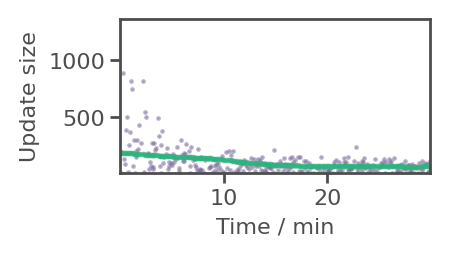

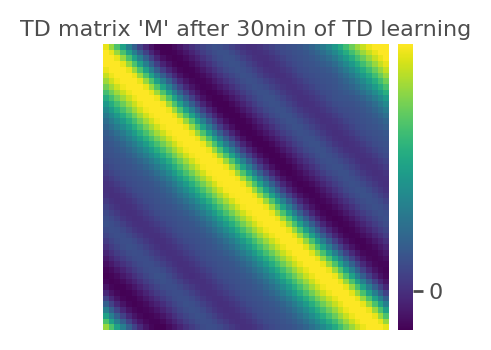

In [43]:
# Set parameters and run simulation
agent_TD.pos = np.array([0,0.1])  
agent_TD.dir = np.array([1,0]) # start at the west end of the loop, facing east, so we can follow the walls in a clockwise direction

# Define agent to train for 30min (as in paper), with TD Learning
agent_TD.runRat(trainTime=30, STDPLearn=False, TDSRLearn=True,saveEvery=None)

# Define what to plot from this STDP run
plotter = Visualiser(agent_TD) # create new plotter to access the data from the STDP run we just did
plotter.plotM(whichM="M", colorbar=True, title="TD matrix 'M' after 30min of TD learning", save=True)

mass ratio = 0.0 vs 0.0 (no theta)


(<Figure size 400x400 with 2 Axes>, array([<Axes: >, <Axes: >], dtype=object))

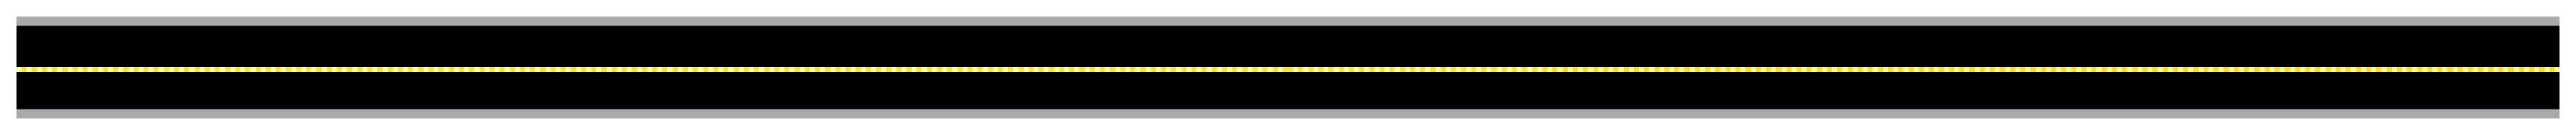

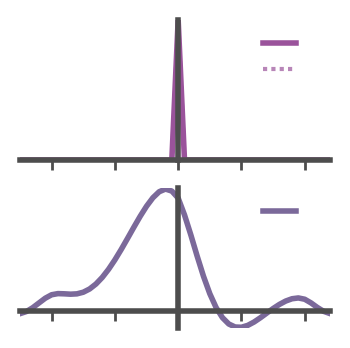

In [99]:
plotter.plotHeatMap(smoothing=1) # bit useless bcs only walks one direction anyways, but oh well...

# make a subplot (or not)
plotter.plotMAveraged(time=None, x_ticks=None, plot_no_theta=True, color='C7',ylim=None, renorm=True)

## Simulation Pipeline with One Agent Learning Both STDP and TD
-> Otherwise the plotMAveraged function can only plot either STDP synaptic weights or TD synaptic weights but not both in the same figure.

The simulation is run with theta = 10Hz

Setting parameters
Initialising
   making state/history dataframes
   initialising velocity, position and direction
   setting time/run counters
   making the maze walls
   discretising position for later plotting
   handling undefined parameters
   initialising basis features for learning
   calculating state vector at all discretised positions


  0%|          | 0/10000 [00:00<?, ?it/s]

   initialising STDP weight matrix and traces
DONE


(<Figure size 4000x160 with 1 Axes>, <Axes: >)

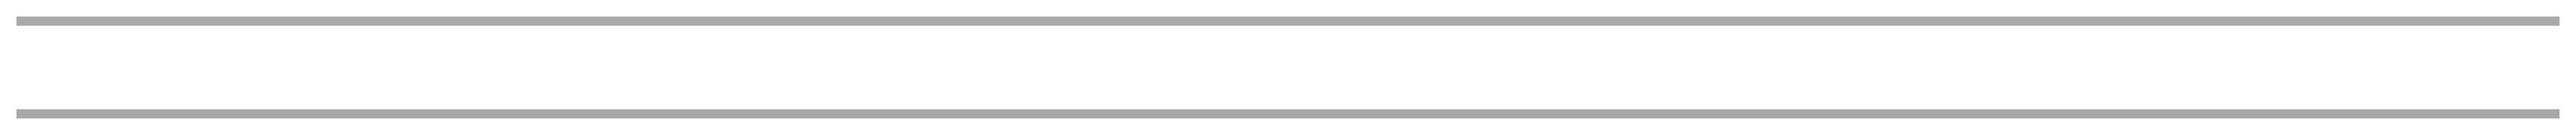

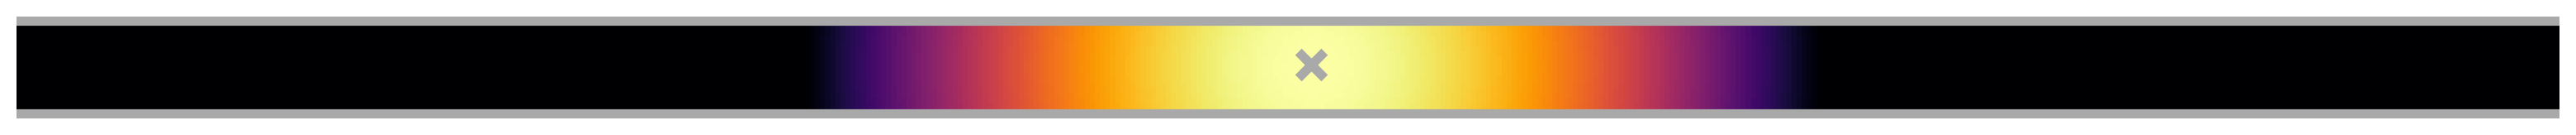

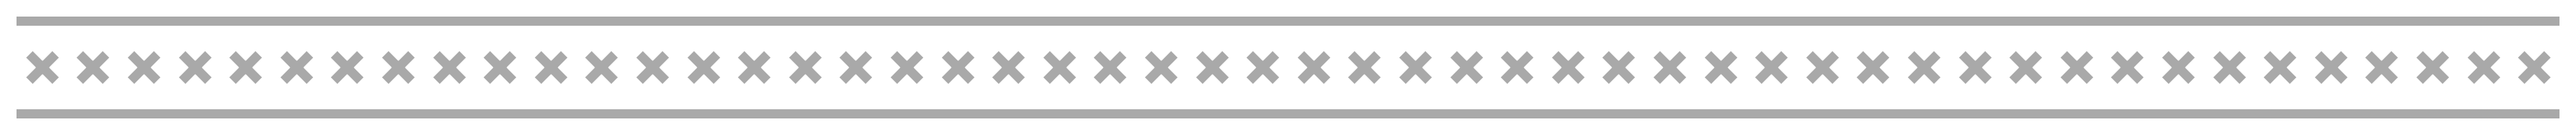

In [40]:
## Define parameters for maze and agent
# number of placeCells
N=50

# set x and y coordinates for place cell centres
xcen = np.linspace(0,5,N+1)[:-1] # we want to place N place cells evenly across the 5m length of the maze, so we create N+1 evenly spaced points and then take all but the last one (which is at 5m) to get the centres of the place cells.
xcen += (xcen[1] - xcen[0]) / 2 # we want the first place cell to be centred at 0.1m, so we shift all the centres by half the distance between them (i.e. the distance between the first centre and 0m) to get the final x coordinates of the place cell centres.
ycen = np.array([0.1]*N) # we want all the place cells to be centred at 0.1m in the y direction (i.e. 10cm from the south wall) so we set all the y coordinates of the place cell centres to 0.1m.
centres = np.vstack((xcen,ycen)).T # we combine the x and y coordinates into a single array of shape (N,2) where each row is the (x,y) coordinates of a place cell centre.

# set parameters for the MazeAgent class
params = {
           #Maze params 
          'mazeType'            : 'loop',  #type of maze, define in getMaze() function
          'stateType'           : 'gaussianThreshold', #feature on which to TD learn (onehot, gaussian, gaussianCS, circles, bump)
          'movementPolicy'      : 'windowsScreensaver',  #movement policy (raudies, random walk, windows screensaver)
          'roomSize'            : 5,          #maze size scaling parameter, metres
          'dt'                  : 0.005,       #simulation time disretisation (defualts to largest )
          'dx'                  : 0.01,       #space discretisation (for plotting, movement is continuous)
          'speedScale'          : 0.16,       #movement speed scale, metres/second
          'rotSpeedScale'       : None,       #rotational speed scale, radians/second
          'initPos'             : None,  #initial position [x0, y0], metres
          'initDir'             : None,      #initial direction, unit vector
          'nCells'              : N,       #how many features to use
          'centres'             : centres,       #array of receptive field positions. Overwrites nCells
          'sigma'               : 1,          #basis cell width scale (irrelevant for onehots)
          'doorsClosed'         : False,       #whether doors are opened or closed in multicompartment maze
          'reorderCells'        : True,       #whether to reorde the cell centres which have been provided
          'firingRateLookUp'    : False,      #use quantised lookup table for firing rates 
          'biasDoorCross'       : False,      #if True, in twoRoom maze door crossings are biased towards
          'biasWallFollow'      : True,       #if True, agent aligns to wall when gets too near.

          #TD params 
          'tau'                 : 4,          #TD decay time, seconds
          'TDdx'                : 0.1,       #rough distance between TD learning updates, metres 
          'alpha'               : 0.01,       #TD learning rate 
          'successorFeatureNorm': 100,        #linear scaling on successor feature definition found to improve learning stability
          'TDreg'               : 0.01,       #L2 regularisation 
          
          #STDP params
          'peakFiringRate'      : 5,          #peak firing rate of a cell (middle of place field,preferred theta phase)
          'tau_STDP_plus'       : 20e-3,      #pre trace decay time
          'tau_STDP_minus'      : 40e-3,      #post trace decay time
          'a_STDP'              : -0.4,       #pre-before-post potentiation factor (post-before-pre = 1) 
          'eta'                 : 0.01,       #STDP learning rate
          'baselineFiringRate'  : 0,          #baseline firing rate for cells 
          'use_full_STDP_rule'  : True,      #whether to use full STDP rule     
          'online_mapping'      : 'identity',  #how to map CA3-->CA1 during learning
          'rownorm'             : False,

          #Theta precession params
          'thetaFreq'           : 10,         #theta frequency
          'precessFraction'     : 0.5,        #fraction of 2pi the prefered phase moves through
          'kappa'               : 1,          # von mises spread parameter
}

agent_2 = MazeAgent(params)
plotter = Visualiser(agent_2)
agent_2.toggleDoors(params['doorsClosed'])

plotter.plotMazeStructure() # plot maze structure to check it's correct before starting simulation
plotter.plotReceptiveField(25) # plot receptive field of place cell 25 in the middel of loop
plotter.plotFeatureCells(centresOnly=True, textlabel=False) # plots centres of the place cells in maze (no heatmap)


  0%|          | 0/360000 [00:00<?, ?it/s]

Calculating place and grid cells
mass ratio = 4.621229251701678 vs 0.9554922898113364 (no theta)
returning data dict
t0.5 2.000 vs t0.5notheta 23.000


(<Figure size 200x400 with 2 Axes>, array([<Axes: >, <Axes: >], dtype=object))

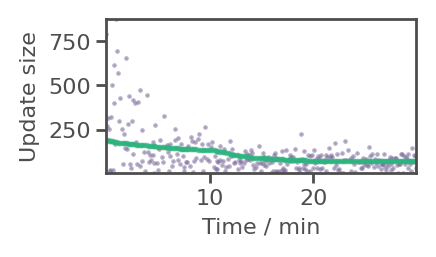

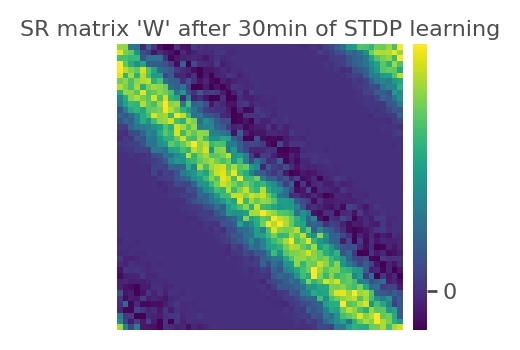

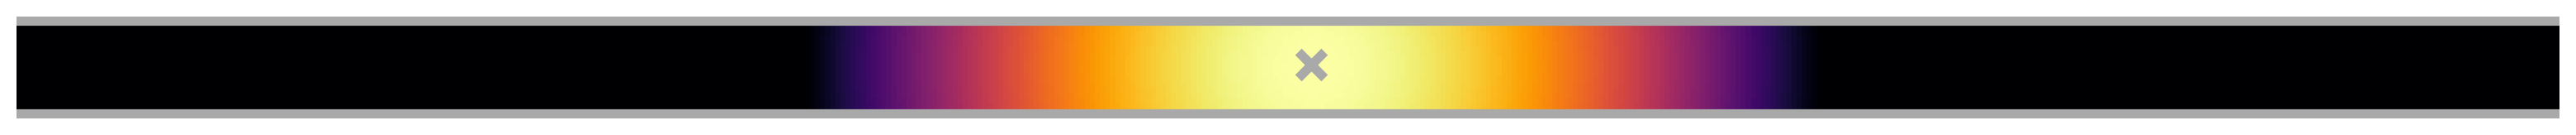

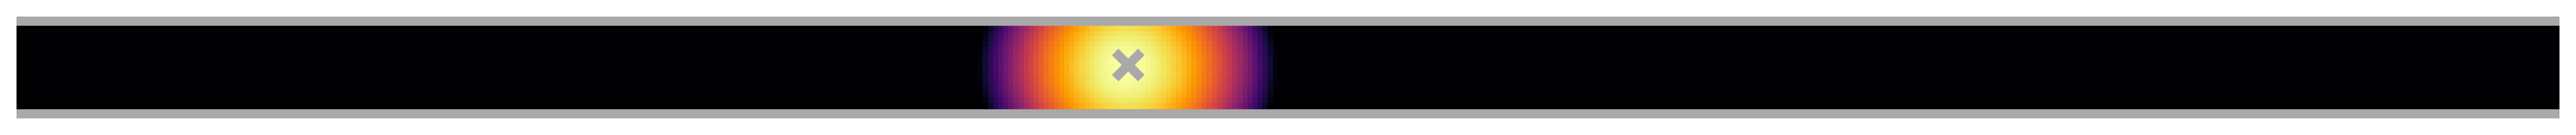

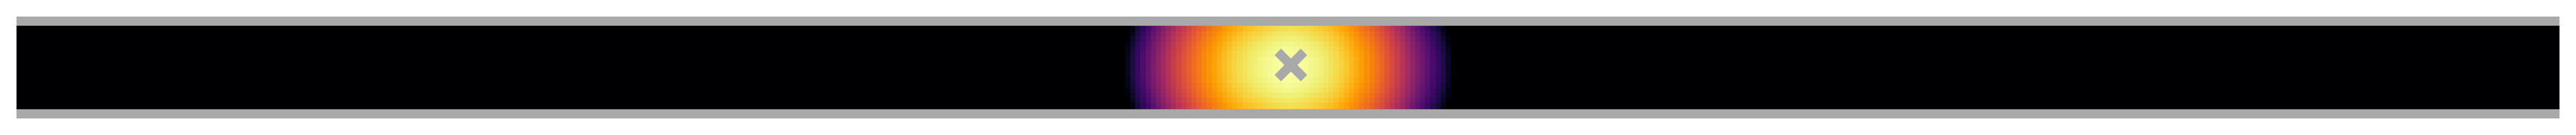

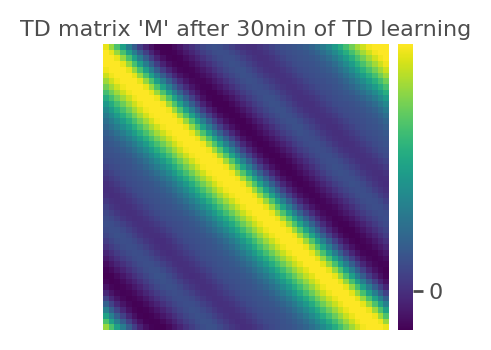

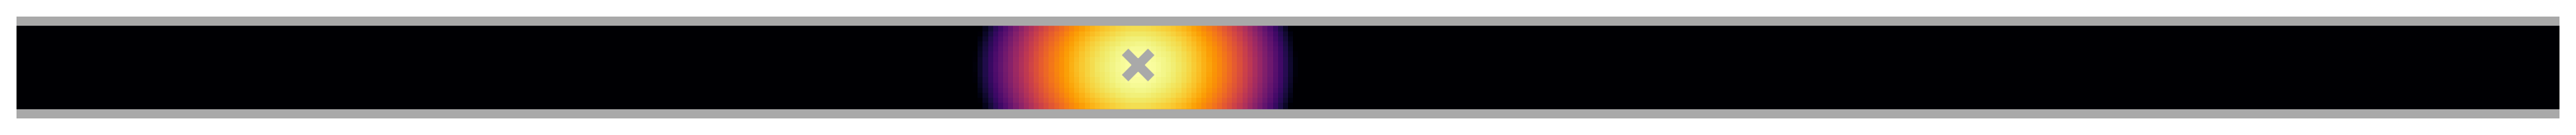

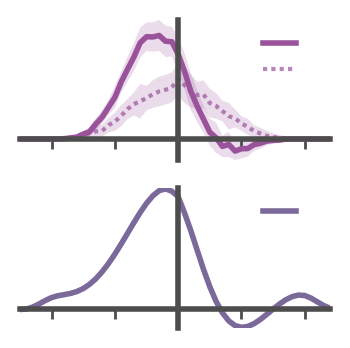

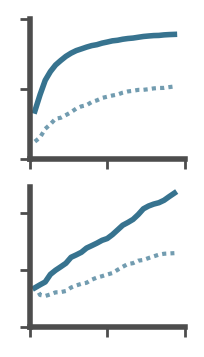

In [41]:
# Set parameters and run simulation
agent_2.pos = np.array([0,0.1])  
agent_2.dir = np.array([1,0]) # start at the west end of the loop, facing east, so we can follow the walls in a clockwise direction

# Define agent to train for 30min (as in paper), with STDP learning, no TD learning and save snapshots every 1min
agent_2.runRat(trainTime=30, STDPLearn=True, TDSRLearn=True, saveEvery=1)

# Define what to plot from this STDP run
plotter = Visualiser(agent_2) # create new plotter to access the data from the STDP run we just did

# Plot STDP plots
# plot STDP weight matrix 'W'
plotter.plotM(whichM="W", colorbar=True, title="SR matrix 'W' after 30min of STDP learning", save=True)
# plot basis feature again
plotter.plotReceptiveField(25)
# plot place field of cell 25 with STDP learning
plotter.plotPlaceField(hist_id=-1, number=25, save=True, STDP=True, no_theta=False)
# plot place field of cell 25 with STDP learning but no theta modulation 
plotter.plotPlaceField(hist_id=-1, number=25, save=True, STDP=True, no_theta=True)


# Plot TD plots
plotter.plotM(whichM="M", colorbar=True, title="TD matrix 'M' after 30min of TD learning", save=True)
# plot place field of cell 25 without STDP learning 
plotter.plotPlaceField(hist_id=-1, number=25, save=True, STDP=False)

# Plot combined plots 
plotter.plotMAveraged(time=None, x_ticks=None, plot_no_theta=True, color='C7',ylim=None, renorm=True, return_data=True)
plotter.plotMetrics(total_time=None, x_ticks=None)

mass ratio = 4.227094527300413 vs 0.9886912952707947 (no theta)
returning data dict


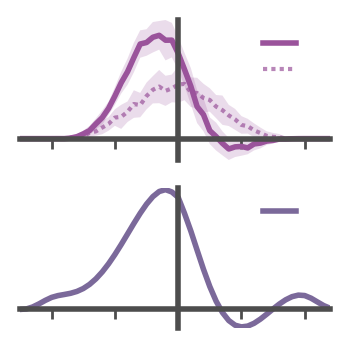

In [163]:
data_dict = plotter.plotMAveraged(time=None, x_ticks=None, plot_no_theta=True, color='C7',ylim=None, renorm=True, return_data=True)

x = data_dict['x']
W_av = data_dict['W_av']
W_std = data_dict['W_std']
M_av = data_dict['M_av']
M_std = data_dict['M_std']
W_notheta_av = data_dict['W_notheta_av']
W_notheta_std = data_dict['W_notheta_std']

##plt.plot(x, W_av)
#plt.fill_between(x, W_av - W_std, W_av + W_std, alpha=0.2)

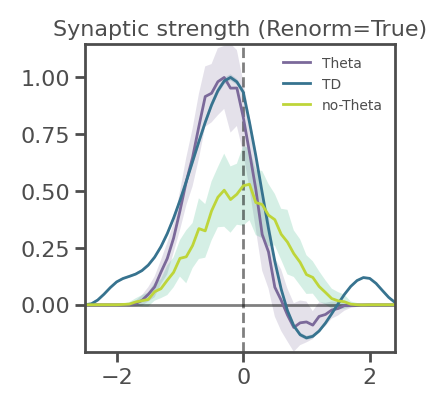

In [164]:
# Plot the raw data as individual plot 

plt.axvline(0, linestyle='--', linewidth=1, alpha=0.5, color= "#0000")
plt.axhline(0, linestyle='-', linewidth=1, alpha=0.5, color= "#0000")

plt.plot(x, W_av, label = "Theta", color = "C0")
plt.fill_between(x, W_av - W_std, W_av + W_std, alpha=0.2)

plt.plot(x, M_av, label = "TD", color = "C1")
plt.fill_between(x, M_av - M_std, M_av + M_std, alpha=0.2)

plt.plot(x, W_notheta_av, label = "no-Theta", color = "C3")
plt.fill_between(x, W_notheta_av - W_notheta_std, W_notheta_av + W_notheta_std, alpha=0.2)


plt.title(label="Synaptic strength (Renorm=True)")

plt.legend(frameon= False, fontsize=5, loc="upper right") #frameon= True would add box around legend

### Questions
1. Why did the STDP Matrix look a bit off in the first run?
2. Why are the successor features not more blurred and wider than the basis feature?
3. What other measures could be used to compare the effect of different theta frequencies on SR formation?
4. Why is there a dip at 0 for both STDP curves?

## Varying Theta Frequency (independent of speed)
Run the simulation from above for different theta frequencies, but same agent running speed.
Specifically for the following theta frequencies:
- 10Hz
- 8Hz
- 6Hz
- 4Hz

Setting parameters
Initialising
   making state/history dataframes
   initialising velocity, position and direction
   setting time/run counters
   making the maze walls
   discretising position for later plotting
   handling undefined parameters
   initialising basis features for learning
   calculating state vector at all discretised positions


  0%|          | 0/10000 [00:00<?, ?it/s]

   initialising STDP weight matrix and traces
DONE


(<Figure size 4000x160 with 1 Axes>, <Axes: >)

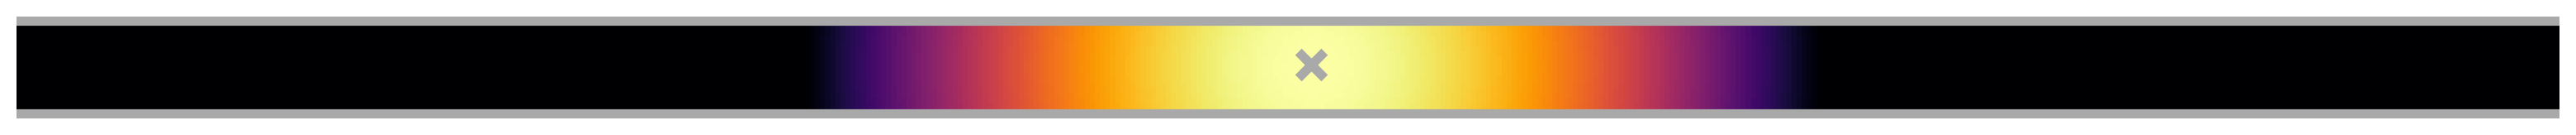

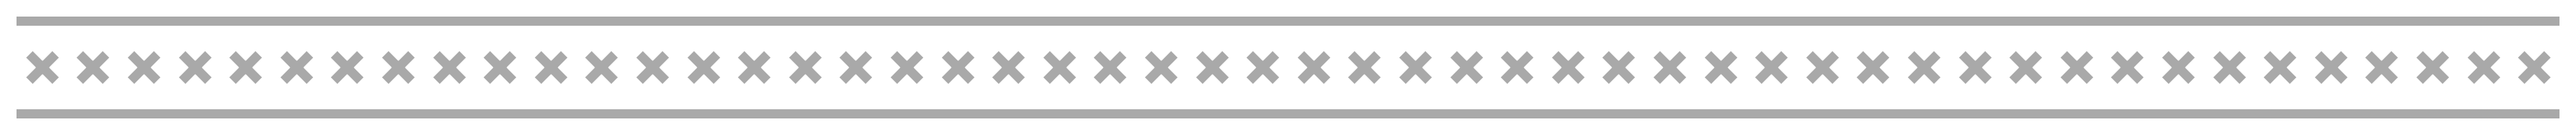

In [38]:
## Define parameters for maze and agent
# number of placeCells
N=50

# set x and y coordinates for place cell centres
xcen = np.linspace(0,5,N+1)[:-1] # we want to place N place cells evenly across the 5m length of the maze, so we create N+1 evenly spaced points and then take all but the last one (which is at 5m) to get the centres of the place cells.
xcen += (xcen[1] - xcen[0]) / 2 # we want the first place cell to be centred at 0.1m, so we shift all the centres by half the distance between them (i.e. the distance between the first centre and 0m) to get the final x coordinates of the place cell centres.
ycen = np.array([0.1]*N) # we want all the place cells to be centred at 0.1m in the y direction (i.e. 10cm from the south wall) so we set all the y coordinates of the place cell centres to 0.1m.
centres = np.vstack((xcen,ycen)).T # we combine the x and y coordinates into a single array of shape (N,2) where each row is the (x,y) coordinates of a place cell centre.
# define list with theta frequencies to loop over later
thetaFreq = [10, 8, 6, 4]

# set parameters for the MazeAgent class
params = {
           #Maze params 
          'mazeType'            : 'loop',  #type of maze, define in getMaze() function
          'stateType'           : 'gaussianThreshold', #feature on which to TD learn (onehot, gaussian, gaussianCS, circles, bump)
          'movementPolicy'      : 'windowsScreensaver',  #movement policy (raudies, random walk, windows screensaver)
          'roomSize'            : 5,          #maze size scaling parameter, metres
          'dt'                  : 0.005,       #simulation time disretisation (defualts to largest )
          'dx'                  : 0.01,       #space discretisation (for plotting, movement is continuous)
          'speedScale'          : 0.16,       #movement speed scale, metres/second
          'rotSpeedScale'       : None,       #rotational speed scale, radians/second
          'initPos'             : None,  #initial position [x0, y0], metres
          'initDir'             : None,      #initial direction, unit vector
          'nCells'              : N,       #how many features to use
          'centres'             : centres,       #array of receptive field positions. Overwrites nCells
          'sigma'               : 1,          #basis cell width scale (irrelevant for onehots)
          'doorsClosed'         : False,       #whether doors are opened or closed in multicompartment maze
          'reorderCells'        : True,       #whether to reorde the cell centres which have been provided
          'firingRateLookUp'    : False,      #use quantised lookup table for firing rates 
          'biasDoorCross'       : False,      #if True, in twoRoom maze door crossings are biased towards
          'biasWallFollow'      : True,       #if True, agent aligns to wall when gets too near.

          #TD params 
          'tau'                 : 4,          #TD decay time, seconds
          'TDdx'                : 0.1,       #rough distance between TD learning updates, metres 
          'alpha'               : 0.01,       #TD learning rate 
          'successorFeatureNorm': 100,        #linear scaling on successor feature definition found to improve learning stability
          'TDreg'               : 0.01,       #L2 regularisation 
          
          #STDP params
          'peakFiringRate'      : 5,          #peak firing rate of a cell (middle of place field,preferred theta phase)
          'tau_STDP_plus'       : 20e-3,      #pre trace decay time
          'tau_STDP_minus'      : 40e-3,      #post trace decay time
          'a_STDP'              : -0.4,       #pre-before-post potentiation factor (post-before-pre = 1) 
          'eta'                 : 0.01,       #STDP learning rate
          'baselineFiringRate'  : 0,          #baseline firing rate for cells 
          'use_full_STDP_rule'  : True,       #whether to use full STDP rule     
          'online_mapping'      : 'identity',  #how to map CA3-->CA1 during learning
          'rownorm'             : False,

          #Theta precession params
          'thetaFreq'           : 10,         #theta frequency as a default -> can't pass list to params
          'precessFraction'     : 0.5,        #fraction of 2pi the prefered phase moves through
          'kappa'               : 1,          # von mises spread parameter
}

agent_Theta = MazeAgent(params)
plotter = Visualiser(agent_Theta)
agent_Theta.toggleDoors(params['doorsClosed'])

# plot only once bcs should look same for all theta
# plotter.plotMazeStructure() # plot maze structure to check it's correct before starting simulation
plotter.plotReceptiveField(25) # plot receptive field of place cell 25 in the middel of loop
plotter.plotFeatureCells(centresOnly=True, textlabel=False) # plots centres of the place cells in maze (no heatmap)


Simulating agent with theta frequency 10Hz
Setting parameters
Initialising
   making state/history dataframes
   initialising velocity, position and direction
   setting time/run counters
   making the maze walls
   discretising position for later plotting
   handling undefined parameters
   initialising basis features for learning
   calculating state vector at all discretised positions


  0%|          | 0/10000 [00:00<?, ?it/s]

   initialising STDP weight matrix and traces
DONE


  0%|          | 0/360000 [00:00<?, ?it/s]

Calculating place and grid cells
mass ratio = 4.490539082600132 vs 0.9834528514162676 (no theta)
returning data dict
t0.5 2.000 vs t0.5notheta 20.000
Simulating agent with theta frequency 8Hz
Setting parameters
Initialising
   making state/history dataframes
   initialising velocity, position and direction
   setting time/run counters
   making the maze walls
   discretising position for later plotting
   handling undefined parameters
   initialising basis features for learning
   calculating state vector at all discretised positions


...

Calculating place and grid cells
mass ratio = 4.905046428688868 vs 0.9709834846511828 (no theta)
returning data dict
t0.5 2.000 vs t0.5notheta 21.000
Simulating agent with theta frequency 4Hz
Setting parameters
Initialising
   making state/history dataframes
   initialising velocity, position and direction
   setting time/run counters
   making the maze walls
   discretising position for later plotting
   handling undefined parameters
   initialising basis features for learning
   calculating state vector at all discretised positions


  0%|          | 0/10000 [00:00<?, ?it/s]

   initialising STDP weight matrix and traces
DONE


  0%|          | 0/360000 [00:00<?, ?it/s]

Calculating place and grid cells
mass ratio = 3.925856356060738 vs 0.9928321086272569 (no theta)
returning data dict
t0.5 2.000 vs t0.5notheta 22.000


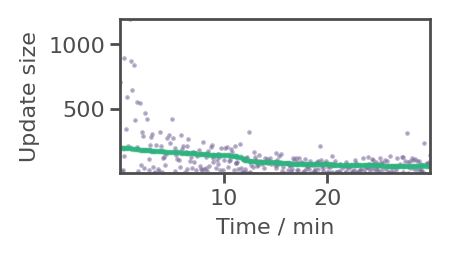

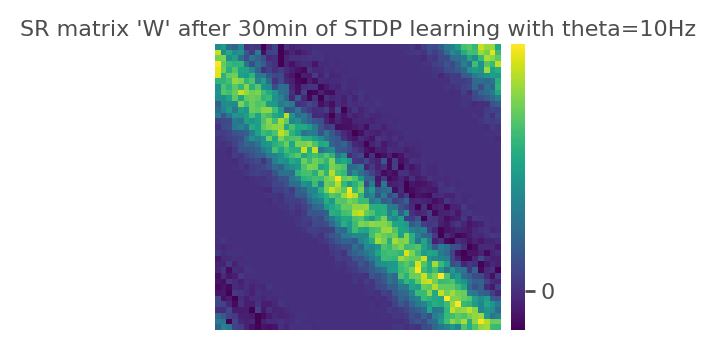

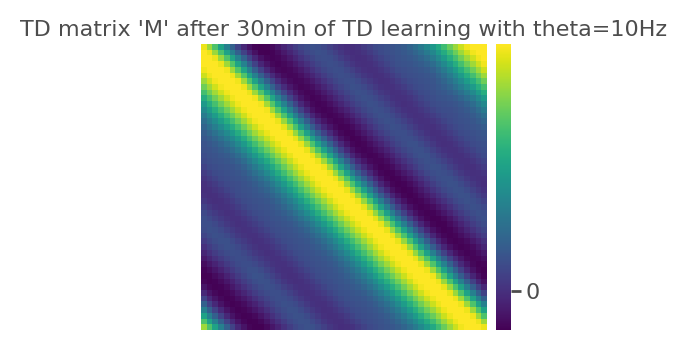

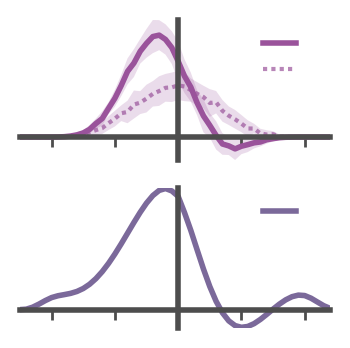

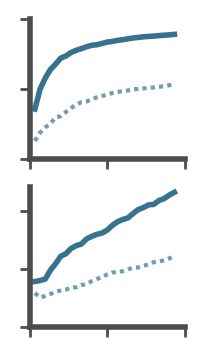

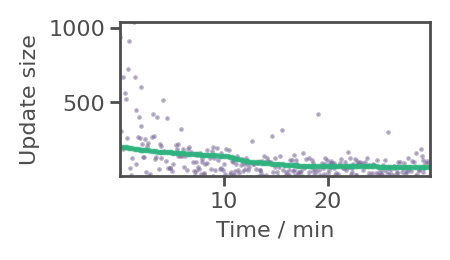

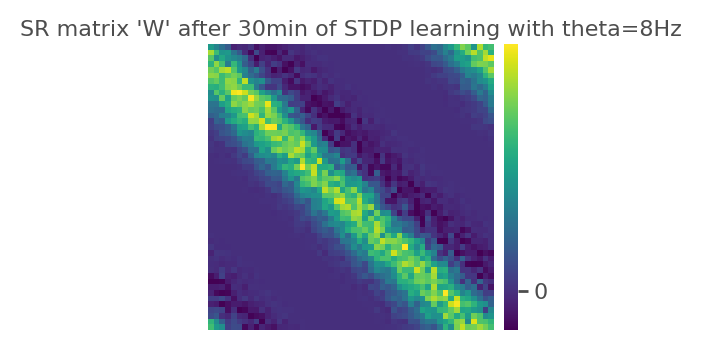

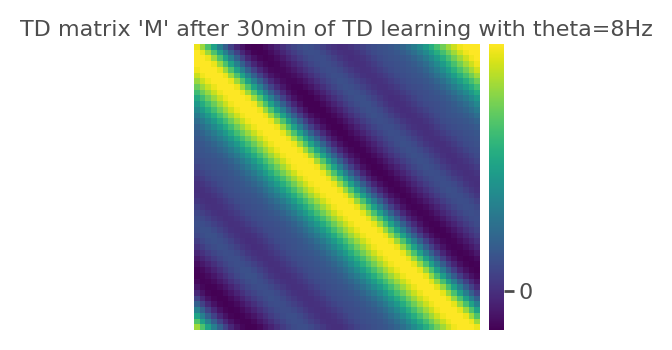

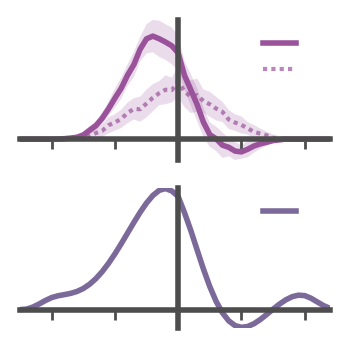

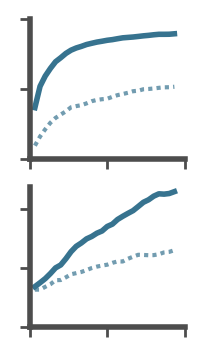

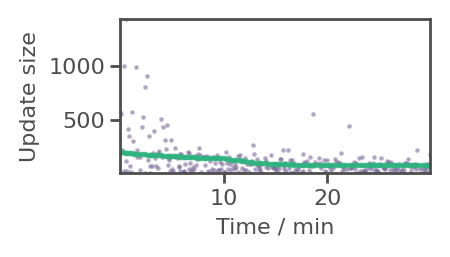

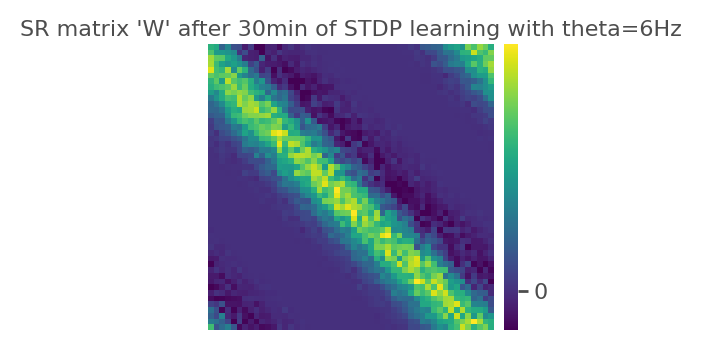

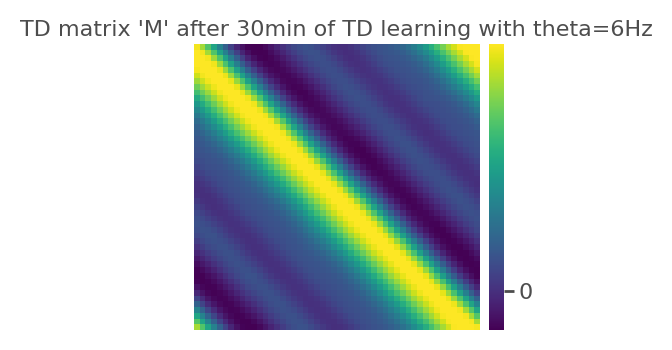

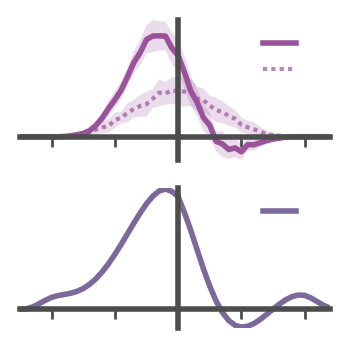

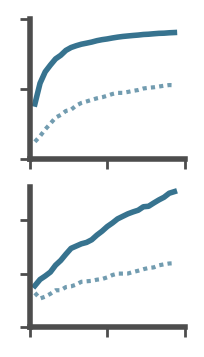

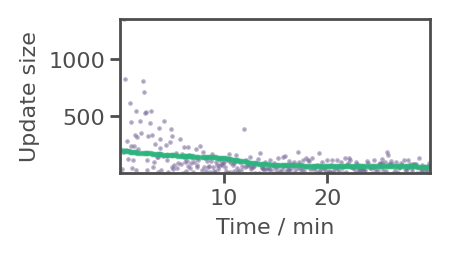

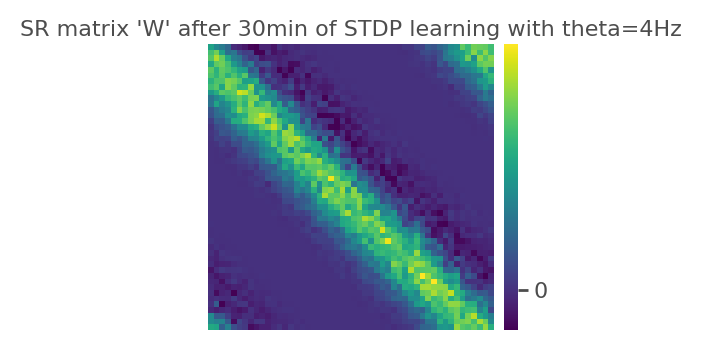

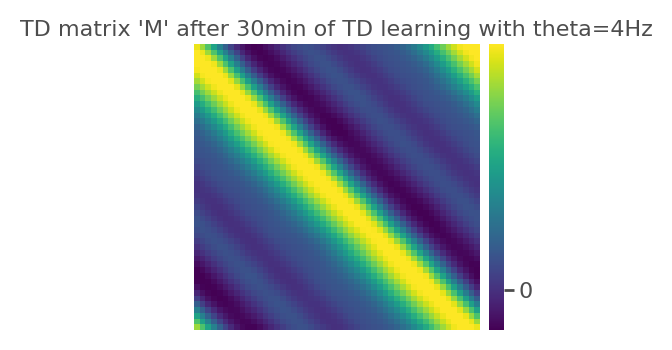

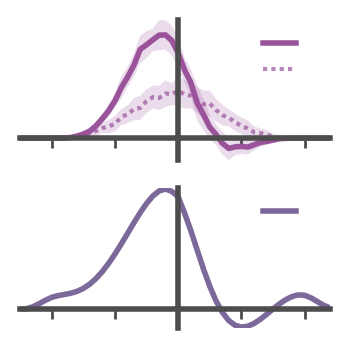

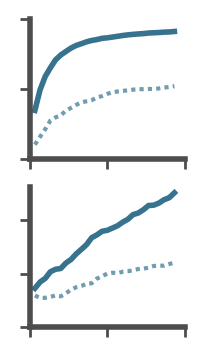

In [39]:
# store agents in case we wanna analyse them later separately
agents = {}
avg_data = {}

# loop over different theta frequencies in list thetaFreq and simulate an agent for each of them
for theta in thetaFreq:
    print(f"Simulating agent with theta frequency {theta}Hz")
    params_list = copy.deepcopy(params)
    params_list['thetaFreq'] = theta

    # recreate the agent, so learning doesn't accumulate across runs
    agent_Theta = MazeAgent(params_list)
    agent_Theta.toggleDoors(params_list['doorsClosed'])

    # reset the starting position and direction for each new agent/run
    agent_Theta.pos = np.array([0,0.1])  
    agent_Theta.dir = np.array([1,0]) 

    # next, run the simulation
    agent_Theta.runRat(trainTime=30, STDPLearn=True, TDSRLearn=True, saveEvery=1)

    # store the agent in a dictionary with the theta frequency as key, so we can access it later for plotting etc
    agents[theta] = agent_Theta

    # use a plotter to visualise the results from this run (optional, can also do it after the loop for all agents)
    plotter = Visualiser(agent_Theta)
    plotter.plotM(whichM="W", colorbar=True, title=f"SR matrix 'W' after 30min of STDP learning with theta={theta}Hz", save=True) 
    # Plot TD plots
    plotter.plotM(whichM="M", colorbar=True, title=f"TD matrix 'M' after 30min of TD learning with theta={theta}Hz", save=True)
    
    # Plot combined plots 
    #save raw data for each frequency
    data_dict=plotter.plotMAveraged(time=None, 
                                    x_ticks=None, 
                                    plot_no_theta=True, 
                                    color='C7',
                                    ylim=None, 
                                    renorm=False, 
                                    return_data=True)
    
    avg_data[theta] = data_dict
    
    plotter.plotMetrics(total_time=None, x_ticks=None)


### Plot figures

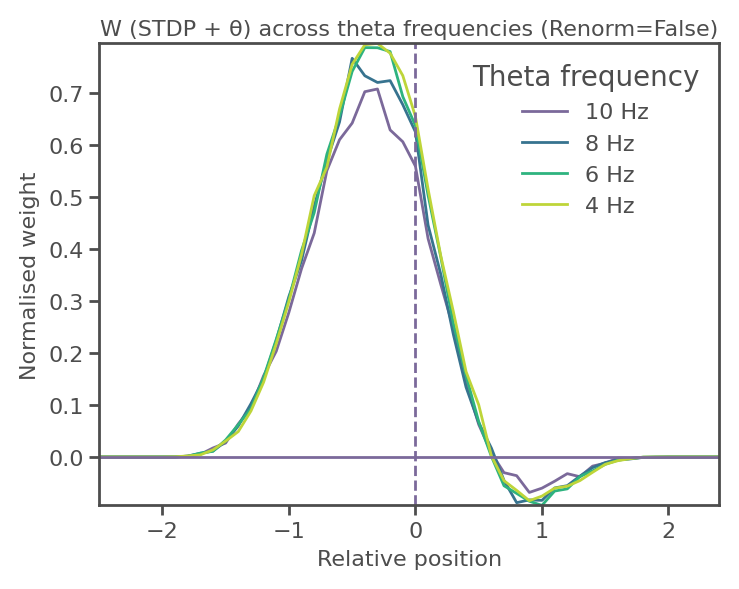

In [172]:
# Plot W for all theta frequencies in one figure
plt.figure(figsize=(4,3))

for theta in thetaFreq:
    data = avg_data[theta]
    x = data['x']
    W_av = data['W_av']

    plt.plot(x, W_av, label=f"{theta} Hz")

plt.axvline(0, linestyle='--', linewidth=1)
plt.axhline(0, linestyle='-', linewidth=1)
plt.legend(title="Theta frequency", frameon= False, fontsize=8, loc="upper right")
plt.title("W (STDP + θ) across theta frequencies (Renorm=False)")
plt.xlabel("Relative position")
plt.ylabel("Normalised weight")
plt.show()


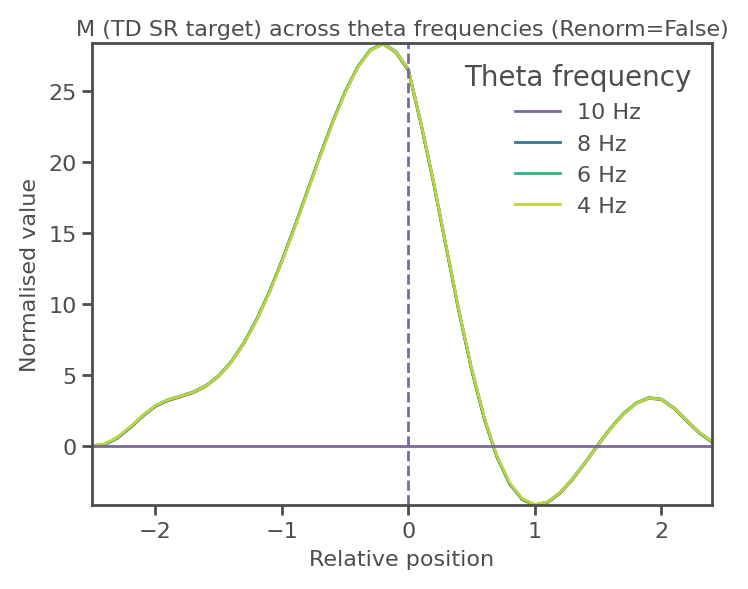

In [173]:
# Plot M for all theta frequencies in one figure 
plt.figure(figsize=(4,3))

for theta in thetaFreq:
    data = avg_data[theta]
    x = data['x']
    M_av = data['M_av']

    plt.plot(x, M_av, label=f"{theta} Hz")

plt.axvline(0, linestyle='--', linewidth=1)
plt.axhline(0, linestyle='-', linewidth=1)
plt.legend(title="Theta frequency", frameon= False, fontsize=8, loc="upper right")
plt.title("M (TD SR target) across theta frequencies (Renorm=False)")
plt.xlabel("Relative position")
plt.ylabel("Normalised value")
plt.show()

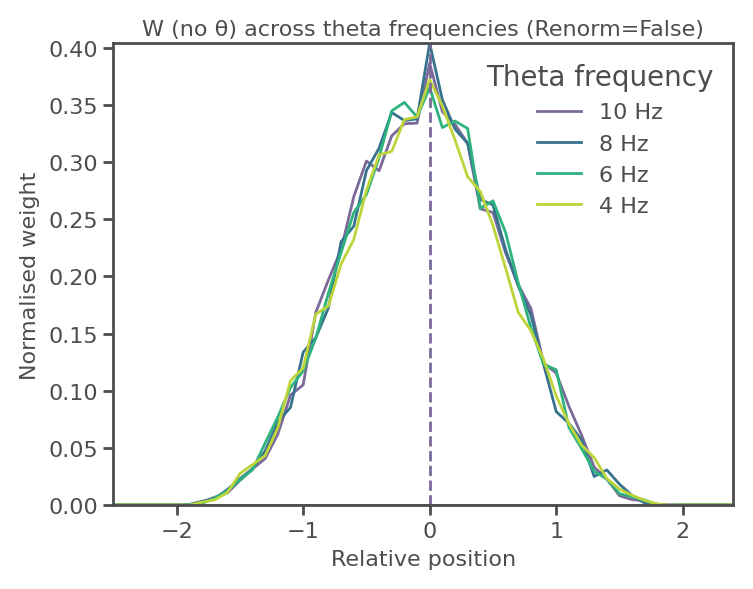

In [175]:
# Plot W-noTheta for all theta frequencies in one figure 
plt.figure(figsize=(4,3))

for theta in thetaFreq:
    data = avg_data[theta]
    x = data['x']
    W_notheta_av = data['W_notheta_av']

    plt.plot(x, W_notheta_av, label=f"{theta} Hz")

plt.axvline(0, linestyle='--', linewidth=1)
plt.axhline(0, linestyle='-', linewidth=1)
plt.legend(title="Theta frequency", frameon= False, fontsize=8, loc="upper right")
plt.title("W (no θ) across theta frequencies (Renorm=False)")
plt.xlabel("Relative position")
plt.ylabel("Normalised weight")
plt.show()

### Output Summary
Below a summary of the output of the simulation with different frequencies (including 10Hz simulation from before)

**Explanation of Metrics**

*Mass ratio:*
- tells us something about the "predictiveness" of the SR
- the mass is basically the total synaptic weight in one half of the profile of the curve
    - if the curve is symmetric: mass ratio = 1
    - if the curve is shifter forward: mass ratio <1
    - if the curve is shifted backwards: mass ratio >1 (-> I guess what we wanna see in the SR)

*t0.5 values:*
- The time at which the learned STDP matrix W reaches 50% similarity to the target matrix M.
-> basically a measure of learning speed

**Theta = 10Hz**:
- mass ratio = 5.013530996744547 vs 0.9940521138346246 (no theta)
- t0.5 2.000 vs t0.5notheta 39.000

**Theta = 8Hz**:
- mass ratio = 5.580463725047294 vs 1.0238391072153867 (no theta)
- t0.5 2.000 vs t0.5notheta 25.000

**Theta = 6Hz**:
- mass ratio = 4.977103396690138 vs 1.0172691181632263 (no theta)
- t0.5 2.000 vs t0.5notheta 26.000

**Theta = 4Hz**:
- mass ratio = 4.678959627358711 vs 0.9823139803104396 (no theta)
- t0.5 2.000 vs t0.5notheta 29.000

## Vary Theta Frequency and Scale it by Locomotor Speed (1st Try)

Setting parameters
Initialising
   making state/history dataframes
   initialising velocity, position and direction
   setting time/run counters
   making the maze walls
   discretising position for later plotting
   handling undefined parameters
   initialising basis features for learning
   calculating state vector at all discretised positions


  0%|          | 0/10000 [00:00<?, ?it/s]

   initialising STDP weight matrix and traces
DONE


(<Figure size 4000x160 with 1 Axes>, <Axes: >)

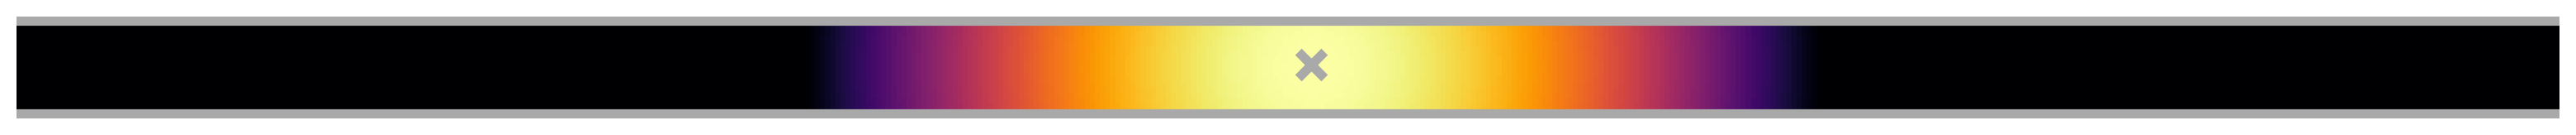

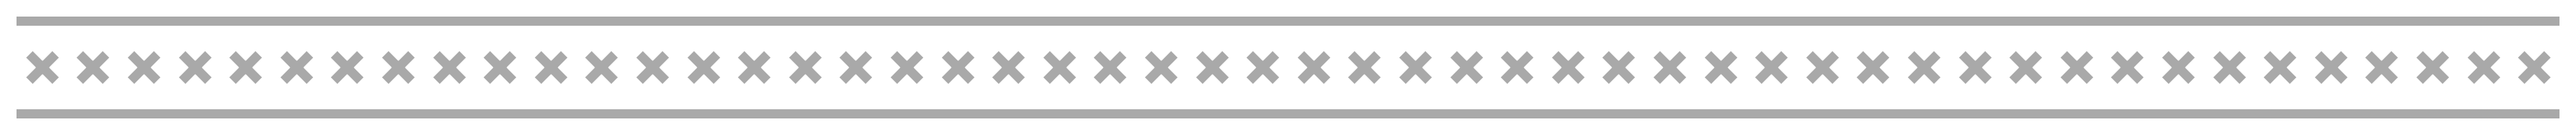

In [176]:
## Define parameters for maze and agent

# number of placeCells
N=50

# set x and y coordinates for place cell centres
xcen = np.linspace(0,5,N+1)[:-1] # we want to place N place cells evenly across the 5m length of the maze, so we create N+1 evenly spaced points and then take all but the last one (which is at 5m) to get the centres of the place cells.
xcen += (xcen[1] - xcen[0]) / 2 # we want the first place cell to be centred at 0.1m, so we shift all the centres by half the distance between them (i.e. the distance between the first centre and 0m) to get the final x coordinates of the place cell centres.
ycen = np.array([0.1]*N) # we want all the place cells to be centred at 0.1m in the y direction (i.e. 10cm from the south wall) so we set all the y coordinates of the place cell centres to 0.1m.
centres = np.vstack((xcen,ycen)).T # we combine the x and y coordinates into a single array of shape (N,2) where each row is the (x,y) coordinates of a place cell centre.
# define list with theta frequencies to loop over later
thetaFreq = [10, 8, 6, 4]

# set parameters for the MazeAgent class
params = {
           #Maze params 
          'mazeType'            : 'loop',  #type of maze, define in getMaze() function
          'stateType'           : 'gaussianThreshold', #feature on which to TD learn (onehot, gaussian, gaussianCS, circles, bump)
          'movementPolicy'      : 'windowsScreensaver',  #movement policy (raudies, random walk, windows screensaver)
          'roomSize'            : 5,          #maze size scaling parameter, metres
          'dt'                  : 0.005,       #simulation time disretisation (defualts to largest )
          'dx'                  : 0.01,       #space discretisation (for plotting, movement is continuous)
          'speedScale'          : 0.16,       #movement speed scale, metres/second
          'rotSpeedScale'       : None,       #rotational speed scale, radians/second
          'initPos'             : None,  #initial position [x0, y0], metres
          'initDir'             : None,      #initial direction, unit vector
          'nCells'              : N,       #how many features to use
          'centres'             : centres,       #array of receptive field positions. Overwrites nCells
          'sigma'               : 1,          #basis cell width scale (irrelevant for onehots)
          'doorsClosed'         : False,       #whether doors are opened or closed in multicompartment maze
          'reorderCells'        : True,       #whether to reorde the cell centres which have been provided
          'firingRateLookUp'    : False,      #use quantised lookup table for firing rates 
          'biasDoorCross'       : False,      #if True, in twoRoom maze door crossings are biased towards
          'biasWallFollow'      : True,       #if True, agent aligns to wall when gets too near.

          #TD params 
          'tau'                 : 4,          #TD decay time, seconds
          'TDdx'                : 0.1,       #rough distance between TD learning updates, metres 
          'alpha'               : 0.01,       #TD learning rate 
          'successorFeatureNorm': 100,        #linear scaling on successor feature definition found to improve learning stability
          'TDreg'               : 0.01,       #L2 regularisation 
          
          #STDP params
          'peakFiringRate'      : 5,          #peak firing rate of a cell (middle of place field,preferred theta phase)
          'tau_STDP_plus'       : 20e-3,      #pre trace decay time
          'tau_STDP_minus'      : 40e-3,      #post trace decay time
          'a_STDP'              : -0.4,       #pre-before-post potentiation factor (post-before-pre = 1) 
          'eta'                 : 0.01,       #STDP learning rate
          'baselineFiringRate'  : 0,          #baseline firing rate for cells 
          'use_full_STDP_rule'  : True,       #whether to use full STDP rule     
          'online_mapping'      : 'identity',  #how to map CA3-->CA1 during learning
          'rownorm'             : False,

          #Theta precession params
          'thetaFreq'           : 10,         #theta frequency as a default -> can't pass list to params
          'precessFraction'     : 0.5,        #fraction of 2pi the prefered phase moves through
          'kappa'               : 1,          # von mises spread parameter
}

agent_Theta = MazeAgent(params)
plotter = Visualiser(agent_Theta)
agent_Theta.toggleDoors(params['doorsClosed'])

# plot only once bcs should look same for all theta
# plotter.plotMazeStructure() # plot maze structure to check it's correct before starting simulation
plotter.plotReceptiveField(25) # plot receptive field of place cell 25 in the middel of loop
plotter.plotFeatureCells(centresOnly=True, textlabel=False) # plots centres of the place cells in maze (no heatmap)


Simulating agent with theta frequency 10Hz
Setting parameters
Initialising
   making state/history dataframes
   initialising velocity, position and direction
   setting time/run counters
   making the maze walls
   discretising position for later plotting
   handling undefined parameters
   initialising basis features for learning
   calculating state vector at all discretised positions


  0%|          | 0/10000 [00:00<?, ?it/s]

   initialising STDP weight matrix and traces
DONE


  0%|          | 0/360000 [00:00<?, ?it/s]

Calculating place and grid cells
mass ratio = 4.277302820302694 vs 0.9479921077907622 (no theta)
returning data dict
t0.5 2.000 vs t0.5notheta 27.000
Simulating agent with theta frequency 8Hz
Setting parameters
Initialising
   making state/history dataframes
   initialising velocity, position and direction
   setting time/run counters
   making the maze walls
   discretising position for later plotting
   handling undefined parameters
   initialising basis features for learning
   calculating state vector at all discretised positions


...

Calculating place and grid cells
mass ratio = 4.325184668271744 vs 0.9279988659283501 (no theta)
returning data dict
t0.5 2.000 vs t0.5notheta 14.000
Simulating agent with theta frequency 4Hz
Setting parameters
Initialising
   making state/history dataframes
   initialising velocity, position and direction
   setting time/run counters
   making the maze walls
   discretising position for later plotting
   handling undefined parameters
   initialising basis features for learning
   calculating state vector at all discretised positions


  0%|          | 0/10000 [00:00<?, ?it/s]

   initialising STDP weight matrix and traces
DONE


  0%|          | 0/360000 [00:00<?, ?it/s]

Calculating place and grid cells
mass ratio = 3.7150085845946785 vs 0.9088969066169378 (no theta)
returning data dict
t0.5 3.000 vs t0.5notheta 11.000


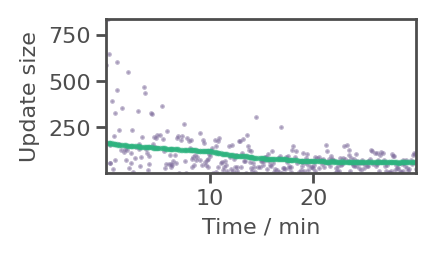

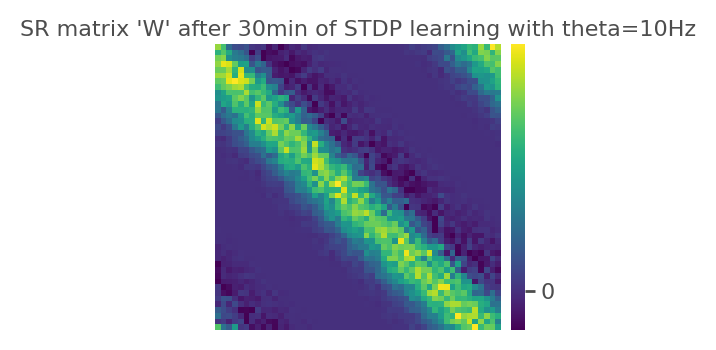

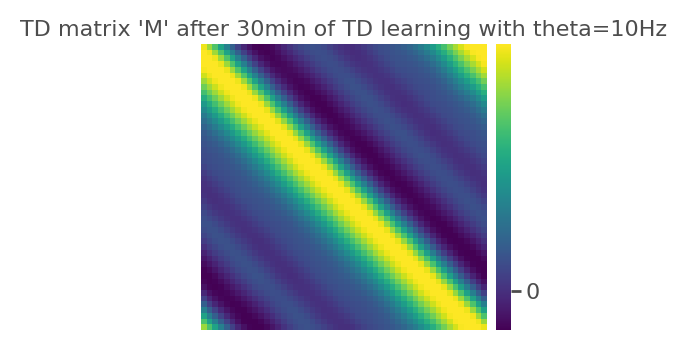

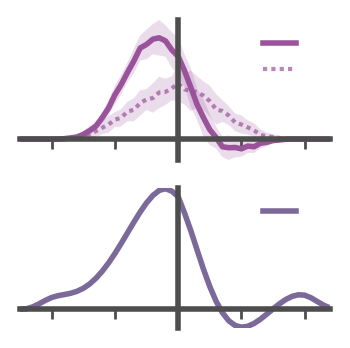

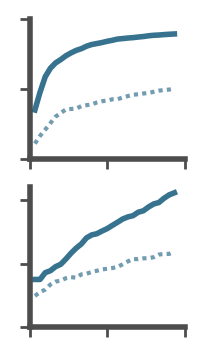

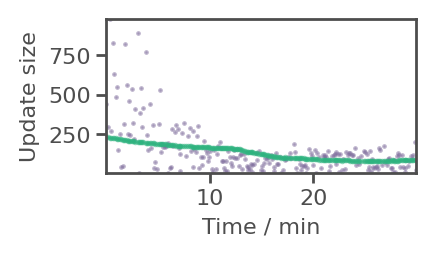

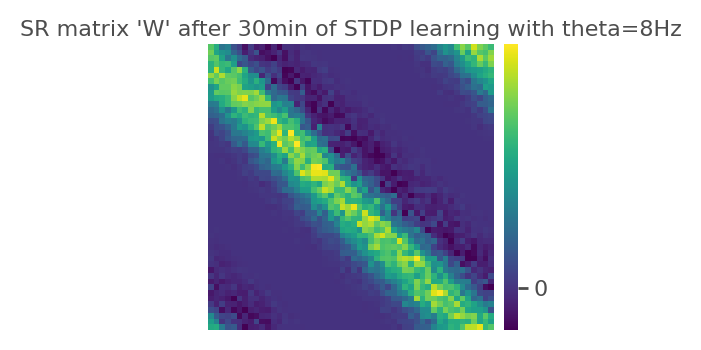

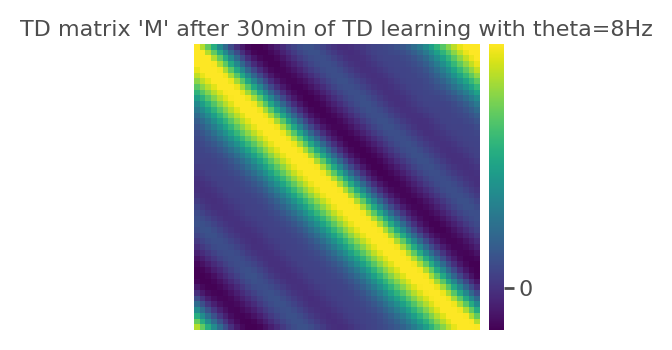

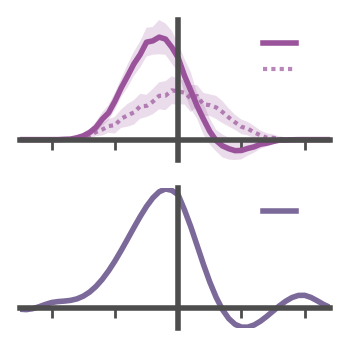

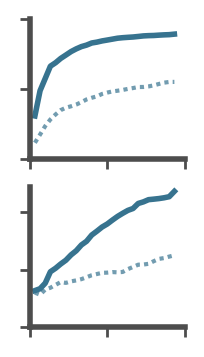

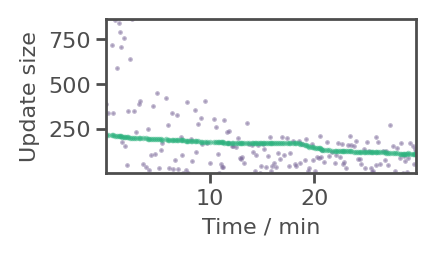

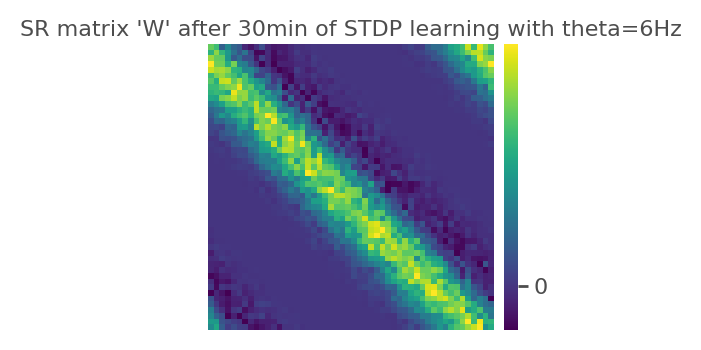

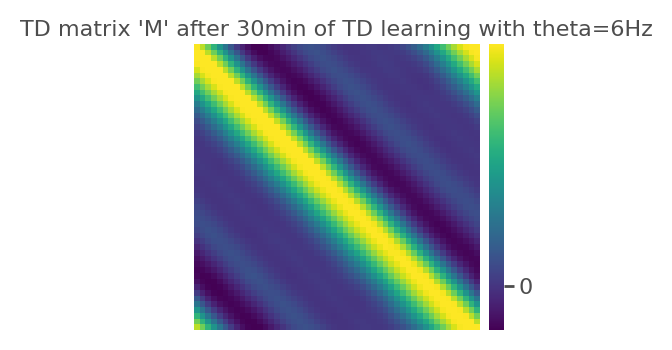

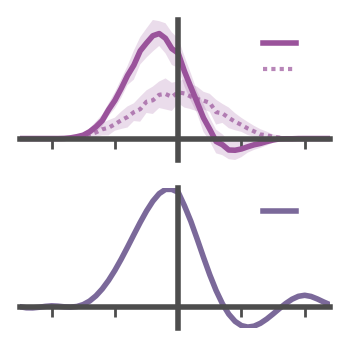

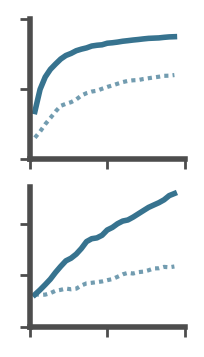

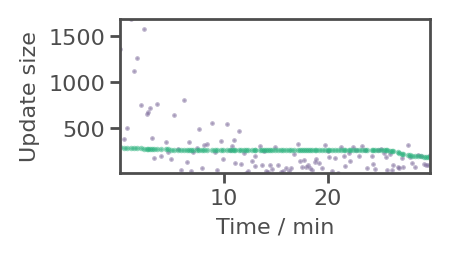

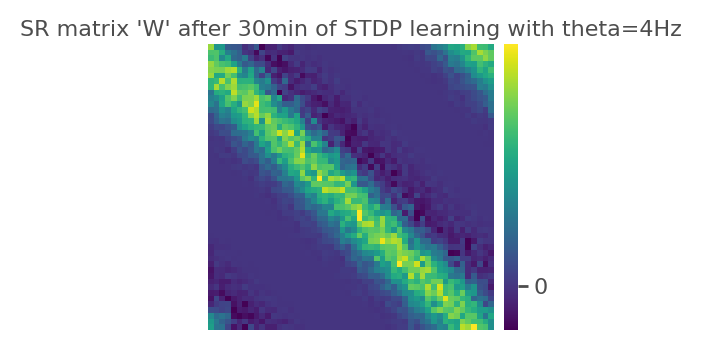

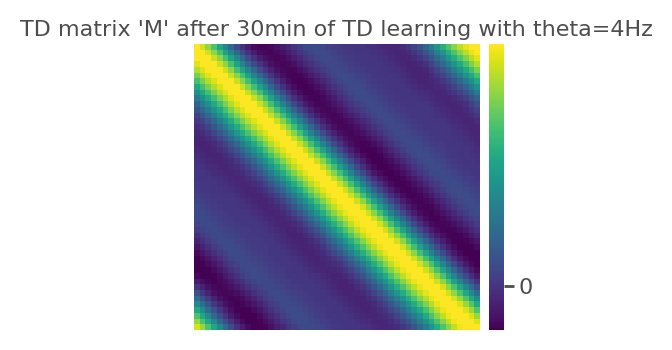

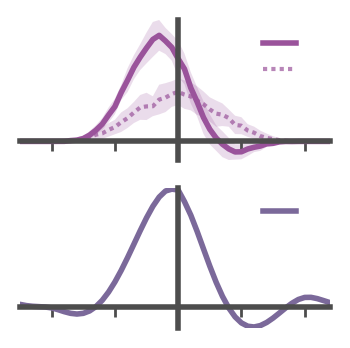

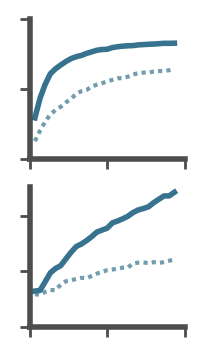

In [177]:
# store agents in case we wanna analyse them later separately
agents = {}
avg_data = {}
# factor for scaling speed
# the default parameters are theta=10Hz & speed=0.16 -> k is hence choosen so that speed = k*theta
# if we solve for k: k=speed/theta = 0.16/10 =0.016
k = 0.016
# effectively speed per theta becomes the following: 10Hz->0.16; 8Hz->0.128; 6Hz->0.096; 4Hz->0.064 

# loop over different theta frequencies in list thetaFreq and simulate an agent for each of them
for theta in thetaFreq:
    print(f"Simulating agent with theta frequency {theta}Hz")
    params_list = copy.deepcopy(params)
    params_list['thetaFreq'] = theta
    params_list['speedScale'] = k * theta

    # recreate the agent, so learning doesn't accumulate across runs
    agent_Theta = MazeAgent(params_list)
    agent_Theta.toggleDoors(params_list['doorsClosed'])

    # reset the starting position and direction for each new agent/run
    agent_Theta.pos = np.array([0,0.1])  
    agent_Theta.dir = np.array([1,0]) 

    # next, run the simulation
    agent_Theta.runRat(trainTime=30, STDPLearn=True, TDSRLearn=True, saveEvery=1)

    # store the agent in a dictionary with the theta frequency as key, so we can access it later for plotting etc
    agents[theta] = agent_Theta

    # use a plotter to visualise the results from this run (optional, can also do it after the loop for all agents)
    plotter = Visualiser(agent_Theta)
    plotter.plotM(whichM="W", colorbar=True, title=f"SR matrix 'W' after 30min of STDP learning with theta={theta}Hz", save=True) 
    # Plot TD plots
    plotter.plotM(whichM="M", colorbar=True, title=f"TD matrix 'M' after 30min of TD learning with theta={theta}Hz", save=True)
    
    # Plot combined plots 
    #save raw data for each frequency
    data_dict=plotter.plotMAveraged(time=None, 
                                    x_ticks=None, 
                                    plot_no_theta=True, 
                                    color='C7',
                                    ylim=None, 
                                    renorm=False, 
                                    return_data=True)
    
    avg_data[theta] = data_dict
    
    plotter.plotMetrics(total_time=None, x_ticks=None)


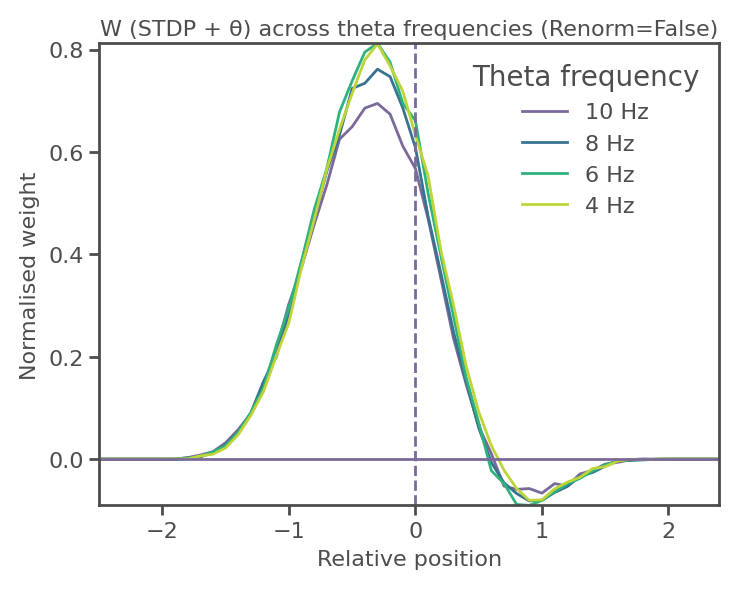

In [178]:
# Plot W for all theta frequencies in one figure
plt.figure(figsize=(4,3))

for theta in thetaFreq:
    data = avg_data[theta]
    x = data['x']
    W_av = data['W_av']

    plt.plot(x, W_av, label=f"{theta} Hz")

plt.axvline(0, linestyle='--', linewidth=1)
plt.axhline(0, linestyle='-', linewidth=1)
plt.legend(title="Theta frequency", frameon= False, fontsize=8, loc="upper right")
plt.title("W (STDP + θ) across theta frequencies (Renorm=False)")
plt.xlabel("Relative position")
plt.ylabel("Normalised weight")
plt.show()

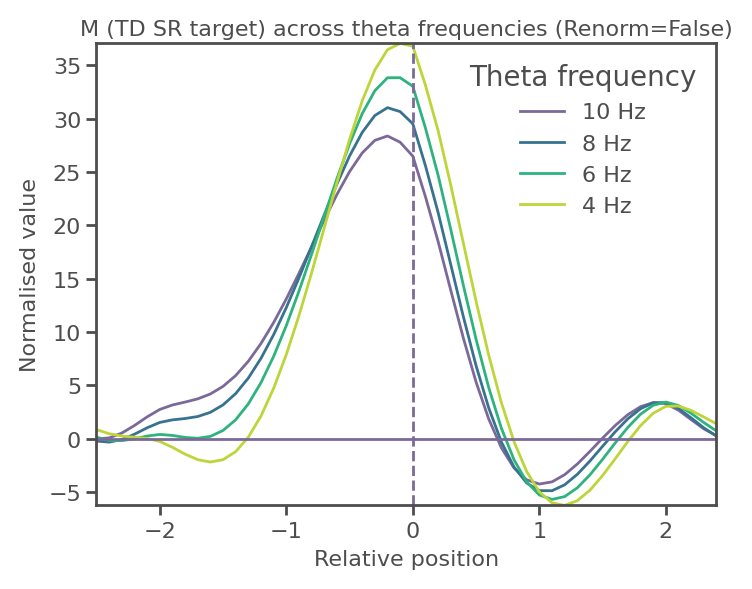

In [179]:
# Plot M for all theta frequencies in one figure 
plt.figure(figsize=(4,3))

for theta in thetaFreq:
    data = avg_data[theta]
    x = data['x']
    M_av = data['M_av']

    plt.plot(x, M_av, label=f"{theta} Hz")

plt.axvline(0, linestyle='--', linewidth=1)
plt.axhline(0, linestyle='-', linewidth=1)
plt.legend(title="Theta frequency", frameon= False, fontsize=8, loc="upper right")
plt.title("M (TD SR target) across theta frequencies (Renorm=False)")
plt.xlabel("Relative position")
plt.ylabel("Normalised value")
plt.show()

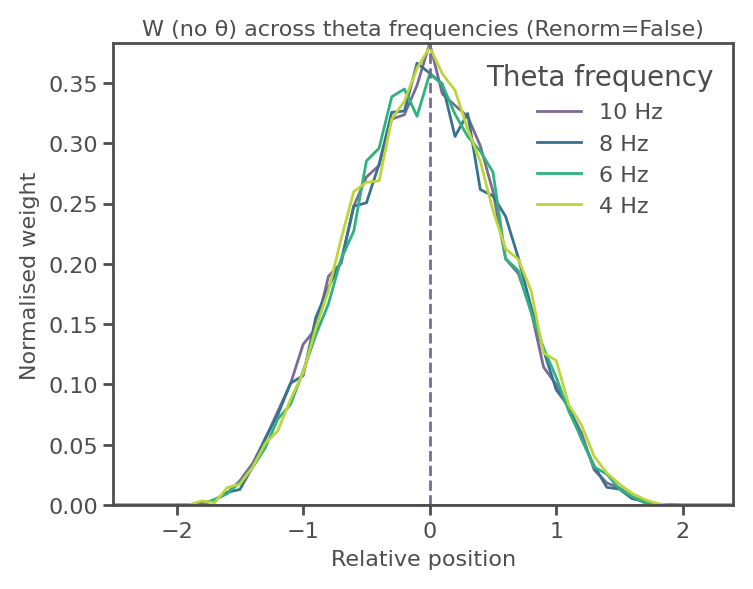

In [180]:
# Plot W-noTheta for all theta frequencies in one figure 
plt.figure(figsize=(4,3))

for theta in thetaFreq:
    data = avg_data[theta]
    x = data['x']
    W_notheta_av = data['W_notheta_av']

    plt.plot(x, W_notheta_av, label=f"{theta} Hz")

plt.axvline(0, linestyle='--', linewidth=1)
plt.axhline(0, linestyle='-', linewidth=1)
plt.legend(title="Theta frequency", frameon= False, fontsize=8, loc="upper right")
plt.title("W (no θ) across theta frequencies (Renorm=False)")
plt.xlabel("Relative position")
plt.ylabel("Normalised weight")
plt.show()

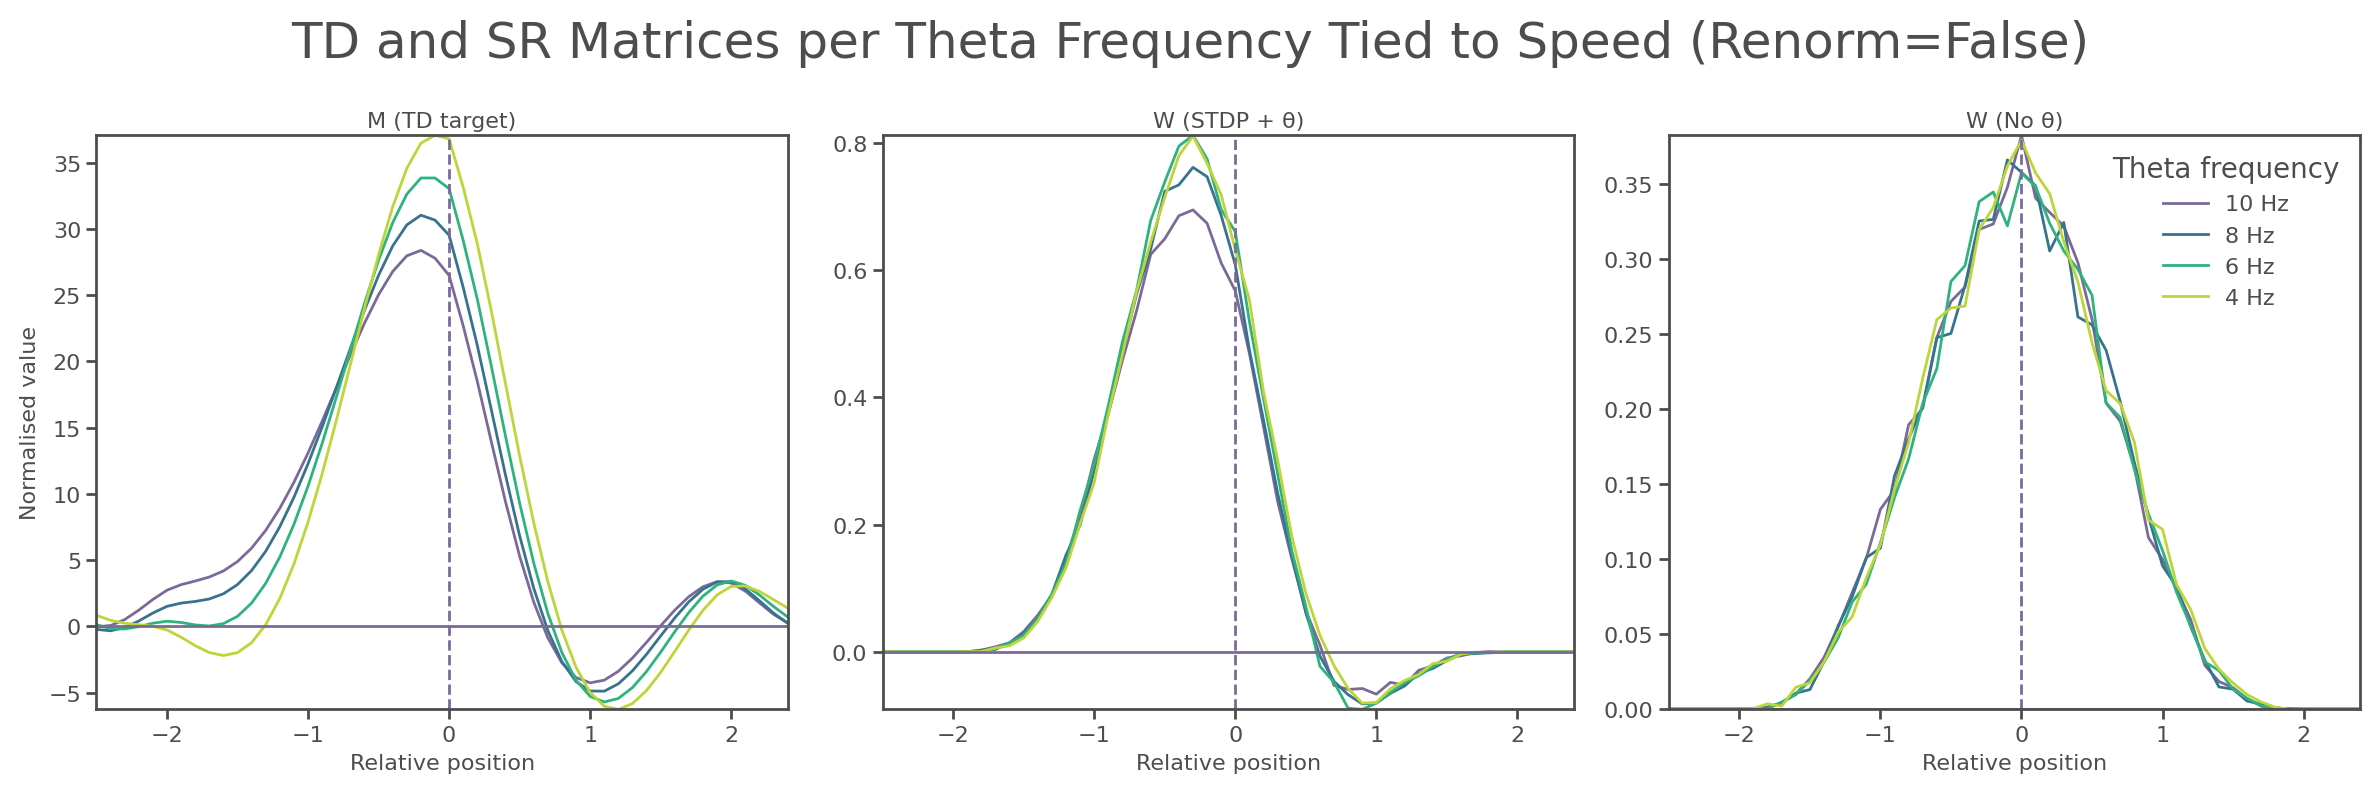

In [ ]:
# combined subplot

fig, ax = plt.subplots(1, 3, figsize=(12,4), sharey= False)

for theta in thetaFreq:
    data = avg_data[theta]
    x = data['x']

    # --- M ---
    ax[0].plot(x, data['M_av'], label=f"{theta} Hz")

    # --- W ---
    ax[1].plot(x, data['W_av'], label=f"{theta} Hz")

    # --- W_noTheta ---
    ax[2].plot(x, data['W_notheta_av'], label=f"{theta} Hz")


# Add vertical & horizontal reference lines
for a in ax:
    a.axvline(0, linestyle='--', linewidth=1)
    a.axhline(0, linestyle='-', linewidth=1)


# Titles
ax[0].set_title("M (TD target)")
ax[1].set_title("W (STDP + θ)")
ax[2].set_title("W (No θ)")


# Labels
ax[0].set_ylabel("Normalised value")
for a in ax:
    a.set_xlabel("Relative position")


# Only show legend once 
ax[2].legend(title="Theta frequency", frameon=False, fontsize=8, loc="upper right")

#
fig.suptitle("TD and SR Matrices per Theta Frequency Tied to Speed (Renorm=False)", fontsize= 18)

plt.tight_layout()
plt.show()

